Imports and General Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import pathlib
import pickle
import copy
import torch
from os import listdir
from os.path import isfile, join
from scipy.stats import sem

# Interactive plots
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

# Project modules (pulls in numpy, pandas, mne, sklearn, pyriemann, etc.)
from src.preprocessing import *
from src.training import *
from src.evaluation import *
from src.group_analysis import *

# Define paths
current_path = pathlib.Path().absolute().parent
recording_path = current_path / 'Recordings'
figure_outputs_path = current_path / 'Figures'

# List available recordings
recording_files = [f for f in listdir(recording_path) if isfile(join(recording_path, f)) and '.xdf' in f]
subject_names = [r.split('_')[0] for r in recording_files]
print('Recording files:', recording_files)
print('Subject IDs:', subject_names)

if not figure_outputs_path.exists():
    print('Output folder does not exist:', figure_outputs_path)

# Electrode groups
Electorde_Groups = {
    'FP': ['Fp1', 'Fp2'],
    'AF': ['AF7', 'AF3', 'AFz', 'AF4', 'AF8'],
    'F':  ['F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8'],
    'FC': ['FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6'],
    'C':  ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6'],
    'CP': ['CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6'],
    'P':  ['P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8'],
    'PO': ['PO7', 'PO3', 'POz', 'PO4', 'PO8'],
    'O':  ['Oz', 'O2', 'O1', 'Iz']
}

# Group tracking
group_results = []

c:\Users\CensorLab\anaconda3\envs\BCIEnvironment\lib\site-packages\moabb\pipelines\__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


Recording files: ['AN_MI1.xdf', 'AN_MI2.xdf', 'AN_MI3.xdf', 'AN_MI4.xdf', 'DD_1.xdf', 'DD_2.xdf', 'DD_3.xdf', 'DD_Idle.xdf', 'EA_MI1.xdf', 'EA_MI2.xdf', 'EA_MI3.xdf', 'EA_MI4.xdf', 'Fudge_MI3_1.xdf', 'Fudge_MI3_2.xdf', 'Fudge_MI3_3.xdf', 'Fudge_MI3_4.xdf', 'Gilad_3rdArm_0804_1.xdf', 'Gilad_3rdArm_0804_2.xdf', 'Gilad_3rdArm_0804_4.xdf', 'Gilad_3rdArm_0804_5.xdf', 'Gilad_RSL1.xdf', 'Gilad_RSL2.xdf', 'ID_MI1.xdf', 'ID_MI2.xdf', 'ID_MI3.xdf', 'JE_Idle.xdf', 'JE_MI1.xdf', 'JE_MI2.xdf', 'JE_MI3.xdf', 'JE_MI4.xdf', 'NC_MI1.xdf', 'NC_MI2.xdf', 'NC_MI3.xdf', 'NC_MI4.xdf', 'NoamV_Idle.xdf', 'NoamV_MI1.xdf', 'NoamV_MI2.xdf', 'NoamV_MI3.xdf', 'NoamV_MI4.xdf', 'Noam_3rdArm_0104_1.xdf', 'Noam_3rdArm_0104_2.xdf', 'Noam_3rdArm_0104_3.xdf', 'Noam_3rdArm_0104_4.xdf', 'NS_MI1.xdf', 'NS_MI2.xdf', 'NS_MI4.xdf', 'NS_MI5.xdf', 'NxSx_MI3x.xdf', 'NZ_MI1.xdf', 'NZ_MI2.xdf', 'NZ_MI3.xdf', 'NZ_MI4.xdf', 'OT_MI1.xdf', 'OT_MI2.xdf', 'Ron_MI_3_1.xdf', 'Ron_MI_3_2.xdf', 'Ron_MI_3_3.xdf', 'Ron_MI_3_4.xdf', 'SK_MI1.xdf

In [2]:
# standard_event_id and remap_epoch_events_to_standard moved to src/preprocessing.py



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # Added missing import
from scipy.stats import sem
from sklearn.metrics import ConfusionMatrixDisplay

# Group analysis functions moved to src/group_analysis.py and src/evaluation.py


In [4]:
# === Example: Manual per-subject runs with group aggregation ===

# Workflow:
# 1. Load a subject's data (epochs, train/val split)
# 2. Run: scores_windows, folds_cm, w_times = run_windowed_classification_aug_cv(...)
# 3. Add to group: add_subject_to_group(group_results, subject_name, scores_windows, folds_cm, w_times)
# 4. Repeat for all subjects
# 5. Plot group results: plot_accuracy_over_time_group(group_results) and plot_average_confusion_fixed_cv_group(group_results)

# Initialize fresh group results for this session
group_results = []

# Example 1: Run Subject 1 (replace with actual subject identifier)
# Assuming you have:
#   - epochs_subject1: MNE Epochs object
#   - epochs_cropped_subject1: Cropped version for training augmentation
#   - cv_split: StratifiedShuffleSplit or similar CV object
#   - params_dict: Parameter dictionary

# Example (do NOT run unless subject 1 is loaded):
'''
scores_windows_s1, folds_cm_s1, w_times_s1 = run_windowed_classification_aug_cv(
    epochs_subject1, 
    epochs_cropped_subject1, 
    cv_split, 
    params_dict, 
    BinaryClassification=False
)
add_subject_to_group(group_results, 'Subject_1', scores_windows_s1, folds_cm_s1, w_times_s1)
'''

# Example 2: Repeat for more subjects
'''
scores_windows_s2, folds_cm_s2, w_times_s2 = run_windowed_classification_aug_cv(...)
add_subject_to_group(group_results, 'Subject_2', scores_windows_s2, folds_cm_s2, w_times_s2)
'''

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'group_results.json')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")


Group results collected for 0 subjects:
Saved 0 subjects to c:\Users\CensorLab\3rd_arm_MI\group_results.json
No subjects with scores_windows available.


TypeError: plot_average_confusion_fixed_cv_group() got an unexpected keyword argument 'window_index'

In [5]:

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'group_results_4_classes_2.json')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes = 4, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")


Group results collected for 0 subjects:
Saved 0 subjects to c:\Users\CensorLab\3rd_arm_MI\group_results_4_classes_2.json
No subjects with scores_windows available.


TypeError: plot_average_confusion_fixed_cv_group() got an unexpected keyword argument 'window_index'

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # Added missing import
from scipy.stats import sem
from sklearn.metrics import ConfusionMatrixDisplay

# Group analysis functions moved to src/group_analysis.py and src/evaluation.py


In [7]:
# === Example: Manual per-subject runs with group aggregation ===

# Workflow:
# 1. Load a subject's data (epochs, train/val split)
# 2. Run: scores_windows, folds_cm, w_times = run_windowed_classification_aug_cv(...)
# 3. Add to group: add_subject_to_group(group_results, subject_name, scores_windows, folds_cm, w_times)
# 4. Repeat for all subjects
# 5. Plot group results: plot_accuracy_over_time_group(group_results) and plot_average_confusion_fixed_cv_group(group_results)

# Initialize fresh group results for this session
group_results = []

# Example 1: Run Subject 1 (replace with actual subject identifier)
# Assuming you have:
#   - epochs_subject1: MNE Epochs object
#   - epochs_cropped_subject1: Cropped version for training augmentation
#   - cv_split: StratifiedShuffleSplit or similar CV object
#   - params_dict: Parameter dictionary

# Example (do NOT run unless subject 1 is loaded):
'''
scores_windows_s1, folds_cm_s1, w_times_s1 = run_windowed_classification_aug_cv(
    epochs_subject1, 
    epochs_cropped_subject1, 
    cv_split, 
    params_dict, 
    BinaryClassification=False
)
add_subject_to_group(group_results, 'Subject_1', scores_windows_s1, folds_cm_s1, w_times_s1)
'''

# Example 2: Repeat for more subjects
'''
scores_windows_s2, folds_cm_s2, w_times_s2 = run_windowed_classification_aug_cv(...)
add_subject_to_group(group_results, 'Subject_2', scores_windows_s2, folds_cm_s2, w_times_s2)
'''

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'group_results.json')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")


Group results collected for 0 subjects:
Saved 0 subjects to c:\Users\CensorLab\3rd_arm_MI\group_results.json
No subjects with scores_windows available.


TypeError: plot_average_confusion_fixed_cv_group() got an unexpected keyword argument 'window_index'

In [8]:

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'group_results_4_classes_2.json')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes = 4, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")


Group results collected for 0 subjects:
Saved 0 subjects to c:\Users\CensorLab\3rd_arm_MI\group_results_4_classes_2.json
No subjects with scores_windows available.


TypeError: plot_average_confusion_fixed_cv_group() got an unexpected keyword argument 'window_index'

Create a parameter dictionary 

In [5]:
params_dict={}
params_dict['PerformCsd']=False
params_dict['PerformAvgRef']=True
Electorde_Group_Names='F+AF+FP+PO+O+FC+C+CP+P'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes ('oioio') # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 8
params_dict['LowPass']=1
params_dict['HighPass']=40
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=1
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='ts+FGDA'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','RightHand','LeftHand','FixatedRest']


note that no bad electrodes were defined for the current subject: oioio


Load XDF files and convert to combined mne Raw instance

In [157]:
xdf_files = [f for f in recording_path.glob('*.xdf') if 'AN' in  f.name] # fill in name to select subject files
#OriginalRaw = Load_and_concatenate_xdf(xdf_files)
xdf_files[:]

[WindowsPath('c:/Users/CensorLab/3rd_arm_MI/Recordings/AN_MI1.xdf'),
 WindowsPath('c:/Users/CensorLab/3rd_arm_MI/Recordings/AN_MI2.xdf'),
 WindowsPath('c:/Users/CensorLab/3rd_arm_MI/Recordings/AN_MI3.xdf'),
 WindowsPath('c:/Users/CensorLab/3rd_arm_MI/Recordings/AN_MI4.xdf')]

In [140]:
# # ---------------------------------------------------------
# # Process IDLE XDF file
# # ---------------------------------------------------------
# params_dict['desired_events'] = ['Idle']

# idle_xdf_file = xdf_files[0]   # <- set this variable above

# print(f"\nProcessing idle file: {idle_xdf_file}")
# raw_idle = read_raw_xdf(idle_xdf_file)

# # Run through the SAME preprocessing (filtering, ICA/autoreject, re-referencing, etc.)
# filtered_idle_raw, idle_epochs, _, _, _ = EEG_Preprocessing(
#     current_path,
#     raw_idle,
#     params_dict
# )

# idle_epochs = remap_epoch_events_to_standard(idle_epochs, standard_event_id, ['Idle'])

# # ---------------------------------------------------------
# # Add idle epochs to your existing epoch list
# # ---------------------------------------------------------

# epochs_list.append(idle_epochs)
# epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')


In [141]:
# Electorde_Group_Names='FP+AF+F+FC+C+CP+P+PO+O'
# params_dict['Electorde_Group']=[] 
# for cur_elec_group_name in Electorde_Group_Names.split('+'):
#     params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
# #Load_and_concatenate_xdf(xdf_files[1:])

In [158]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[:]:
    raw=read_raw_xdf(xdf_file)
    # Step 1: move all affected channels to temporary names
    raw.rename_channels({
        'F8':   '_tmp_F8',   'F4':   '_tmp_F4',
        'FC2':  '_tmp_FC2',  'FT10': '_tmp_FT10',
        'Cz':   '_tmp_Cz',   'T8':   '_tmp_T8',
        'CP2':  '_tmp_CP2',  'CP6':  '_tmp_CP6',
        'P4':   '_tmp_P4',   'TP10': '_tmp_TP10',
        'P7':   '_tmp_P7',   'P3':   '_tmp_P3',
        'Pz':   '_tmp_Pz',   'CP1':  '_tmp_CP1',
        'CP5':  '_tmp_CP5',  'TP9':  '_tmp_TP9',
    })

    # Step 2: rename temps to their final destinations
    raw.rename_channels({
        # swaps
        '_tmp_F8':   'F4',   '_tmp_F4':   'F8',
        '_tmp_FC2':  'FT10', '_tmp_FT10': 'FC2',
        '_tmp_Cz':   'T8',   '_tmp_T8':   'Cz',
        '_tmp_CP2':  'CP6',  '_tmp_CP6':  'CP2',
        '_tmp_P4':   'TP10', '_tmp_TP10': 'P4',
        # cycle: P7→P3→Pz→CP1→CP5→TP9→P7
        '_tmp_P7':  'P3',
        '_tmp_P3':  'Pz',
        '_tmp_Pz':  'CP1',
        '_tmp_CP1': 'CP5',
        '_tmp_CP5': 'TP9',
        '_tmp_TP9': 'P7',
    })
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    #raw_for_ICA = raw_EEG_Preprocessing(current_path,raw,params_dict)
    filtered_raw,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict, pick_channels=False)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None
epochs

Creating RawArray with float64 data, n_channels=67, n_times=377256
    Range : 0 ... 377255 =      0.000 ...   754.510 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass fo

Number of events,220
Events,ClosePalm: 60FixatedRest: 40LeftHand: 60RightHand: 60
Time range,-5.000 – 6.000 s
Baseline,off


In [159]:

# balance_epochs_by_subsampling moved to src/preprocessing.py
balanced_epochs = balance_epochs_by_subsampling(epochs, class_to_subsample='Rest')
epochs = balanced_epochs

## ICA on Combined Epochs
Fit ICA on the concatenated epochs to identify and remove artifactual components (eye blinks, muscle, etc.).  
**Workflow:**  
1. Run the cell below to fit ICA and inspect component plots.  
2. Set `ica.exclude = [...]` with the component indices you want to remove.  
3. Run the "Apply ICA" cell to get `epochs_ica` (cleaned epochs).

In [160]:
from mne.preprocessing import ICA

# ---- Fit ICA on combined epochs (simple version) ----
_n_components_epochs = min(25, len(epochs.ch_names) - 1)

# Build a continuous Raw from the epoch data
data = epochs.get_data()  # (n_epochs, n_ch, n_times)
data_concat = data.transpose(1, 0, 2).reshape(len(epochs.ch_names), -1)
raw_from_epochs = mne.io.RawArray(data_concat, epochs.info.copy())

print("Fitting ICA on epoch data...")
ica = ICA(
    n_components=_n_components_epochs,
    method="fastica",
    random_state=97
)
ica.fit(raw_from_epochs, decim=3)
print(f"✅ ICA fitted ({ica.n_components_} components).")

# Plot components for visual inspection
ica.plot_components()
ica.plot_sources(raw_from_epochs, start=0, stop=60)

print(f"\nCurrent ica.exclude = {ica.exclude}")


Creating RawArray with float64 data, n_channels=64, n_times=1210220
    Range : 0 ... 1210219 =      0.000 ...  2420.438 secs
Ready.
Fitting ICA on epoch data...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 25 components
Fitting ICA took 10.1s.
✅ ICA fitted (25 components).
Creating RawArray with float64 data, n_channels=25, n_times=1210220
    Range : 0 ... 1210219 =      0.000 ...  2420.438 secs
Ready.

Current ica.exclude = []


Creating RawArray with float64 data, n_channels=25, n_times=1210220
    Range : 0 ... 1210219 =      0.000 ...  2420.438 secs
Ready.


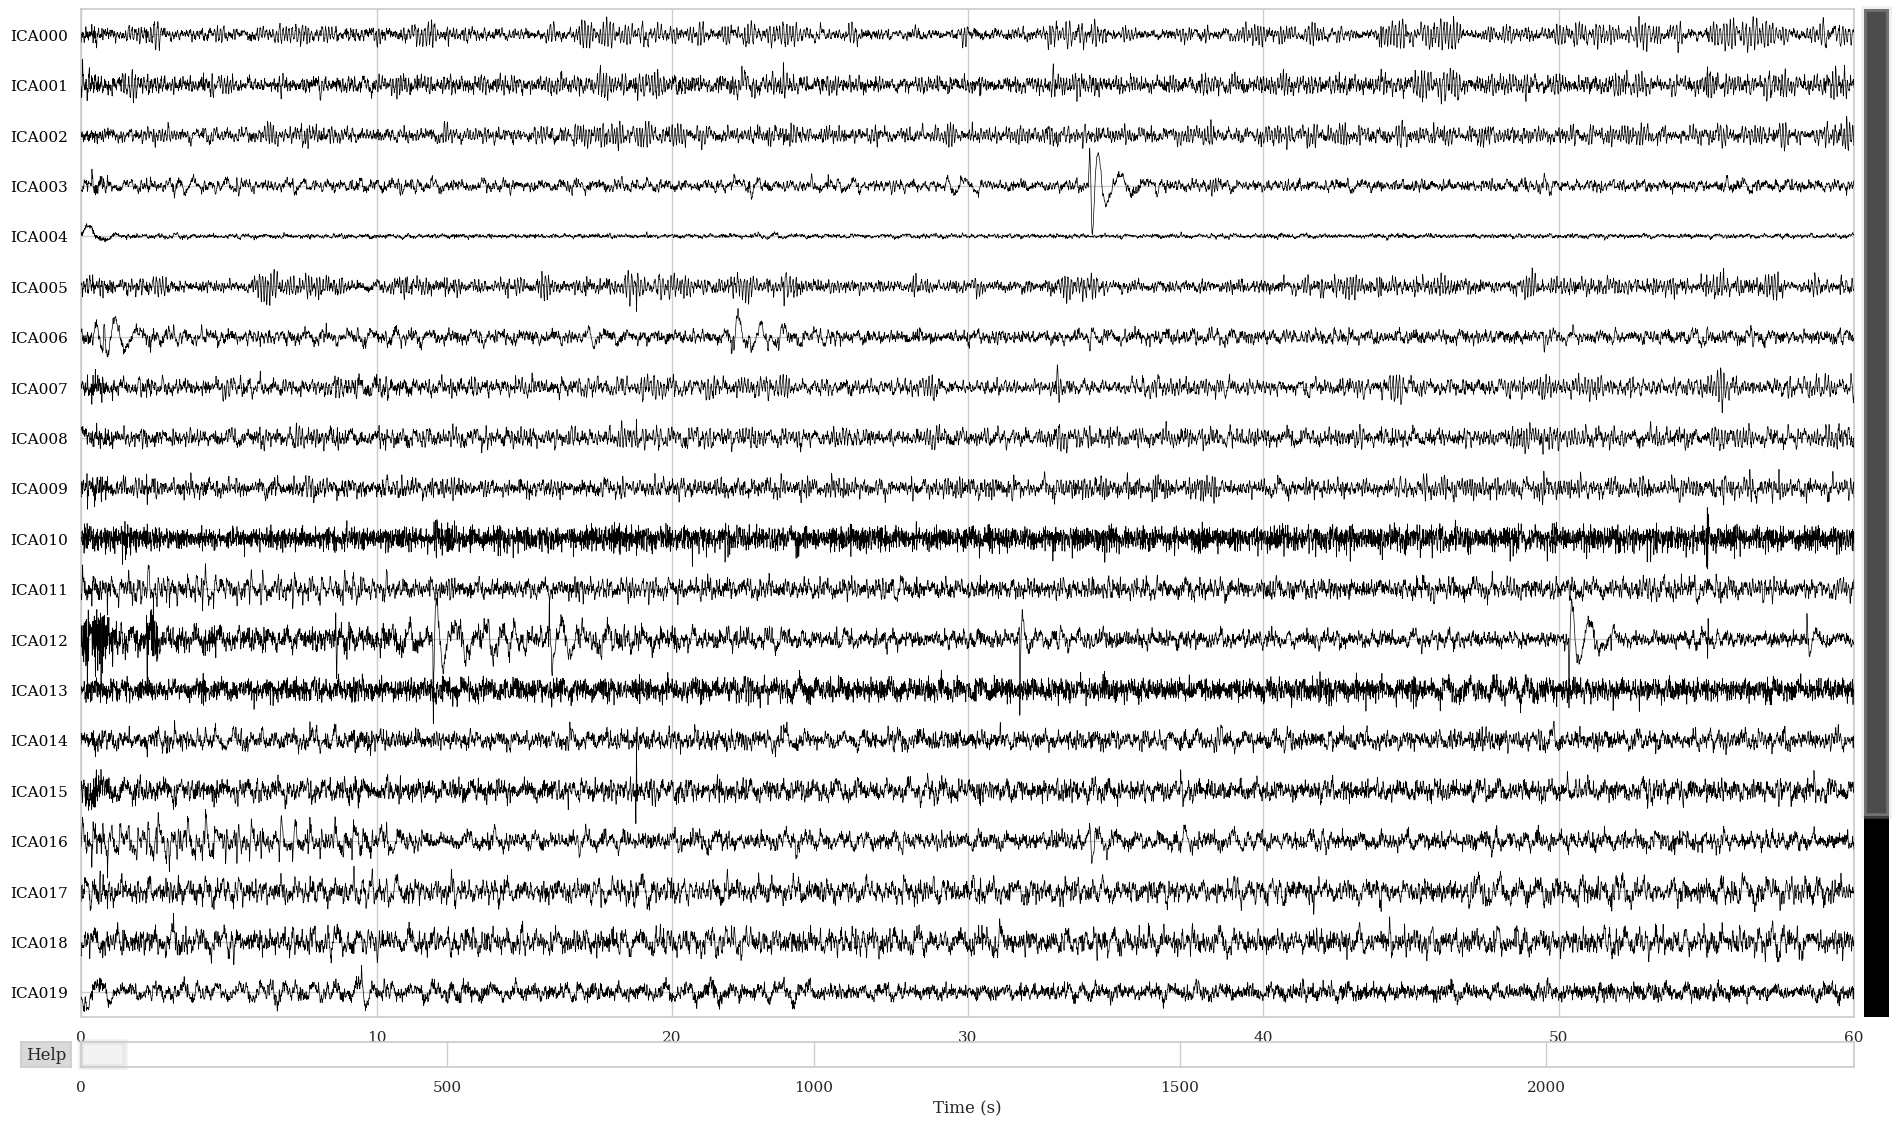

In [161]:
# Plot components for visual inspection
ica.plot_components()
ica.plot_sources(raw_from_epochs, start=0, stop=60)

In [162]:
# Run ICLabel classification
from mne_icalabel import label_components
import pandas as pd
print("Running ICLabel classification...")
label_dict = label_components(raw_from_epochs, ica, method='iclabel')




Running ICLabel classification...


In [163]:
# Display results
print("\nICLabel results:")
print(f"Keys in label_dict: {label_dict.keys()}")
print(f"\nComponent labels: {label_dict['y_pred_proba']}")
print(f"\nComponent labels: {label_dict['labels']}")

# You can then manually set ica.exclude based on the labels
# For example, exclude eye and muscle artifacts:
exclude_labels = ['eye blink', 'eye movement', 'muscle artifact']
auto_exclude = [i for i, label in enumerate(label_dict['labels']) if label in exclude_labels]
print(f"\nSuggested exclusions: {auto_exclude}")


ICLabel results:
Keys in label_dict: dict_keys(['y_pred_proba', 'labels'])

Component labels: [0.9995455  0.99994904 0.9999836  0.99297106 0.90090173 0.9989536
 0.9996779  0.9962789  0.9960434  0.99947214 0.64351094 0.9856657
 0.5257334  0.44547737 0.8863211  0.9204323  0.64643174 0.77747273
 0.8553597  0.86952215 0.91804683 0.36308622 0.7275733  0.74395823
 0.6641433 ]

Component labels: ['brain', 'brain', 'brain', 'eye blink', 'other', 'brain', 'eye blink', 'brain', 'brain', 'brain', 'muscle artifact', 'brain', 'brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'other', 'muscle artifact', 'muscle artifact', 'channel noise', 'brain', 'brain', 'brain']

Suggested exclusions: [3, 6, 10, 16, 19, 20]


In [164]:
# Display results in a nice table format
import pandas as pd

print("\nICLabel results:")
print(f"Keys in label_dict: {label_dict.keys()}")

# Create a nice table showing component number, label, and probability
ic_labels = label_dict['labels']
ic_probs = label_dict['y_pred_proba']

# Build results table
results = []
for idx, (label, prob) in enumerate(zip(ic_labels, ic_probs)):
    # If prob is a 1D value
    if hasattr(prob, '__len__') and len(prob) > 1:
        # It's an array of probabilities for all classes
        max_prob = prob.max()
    else:
        # It's a single probability value
        max_prob = prob
    
    results.append({
        'Component': idx,
        'Label': label,
        'Probability': f"{max_prob:.3f}"
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# You can then manually set ica.exclude based on the labels
# For example, exclude eye and muscle artifacts:
exclude_labels = ['eye blink', 'eye movement', 'muscle artifact']
auto_exclude = [i for i, label in enumerate(ic_labels) if label in exclude_labels]
print(f"\nSuggested exclusions based on labels {exclude_labels}:")
print(f"Components to exclude: {auto_exclude}")



ICLabel results:
Keys in label_dict: dict_keys(['y_pred_proba', 'labels'])

 Component           Label Probability
         0           brain       1.000
         1           brain       1.000
         2           brain       1.000
         3       eye blink       0.993
         4           other       0.901
         5           brain       0.999
         6       eye blink       1.000
         7           brain       0.996
         8           brain       0.996
         9           brain       0.999
        10 muscle artifact       0.644
        11           brain       0.986
        12           brain       0.526
        13           brain       0.445
        14           brain       0.886
        15           brain       0.920
        16       eye blink       0.646
        17           brain       0.777
        18           other       0.855
        19 muscle artifact       0.870
        20 muscle artifact       0.918
        21   channel noise       0.363
        22           brain

In [165]:
print(f"Components to remove: {ica.exclude}")

Components to remove: [3, 4, 6, 10, 16, 19, 20, 21]


In [166]:
# ---- Set excluded components and apply ICA ----
# Uncomment and edit the line below after inspecting the plots:
# ica.exclude = [0, 3]   # <-- put your component indices here

print(f"Components to remove: {ica.exclude}")
epochs = apply_ica_to_epochs(ica, epochs)

# Now reduce to the electrode group of interest
filtered_electrodes = [elec for elec in params_dict["Electorde_Group"] if elec in epochs.ch_names]
epochs.pick(filtered_electrodes)
print(f"Picked {len(filtered_electrodes)} channels: {filtered_electrodes[:5]}...")
epochs

Components to remove: [3, 4, 6, 10, 16, 19, 20, 21]
Applying ICA — removing components: [3, 4, 6, 10, 16, 19, 20, 21]
Creating RawArray with float64 data, n_channels=64, n_times=1210220
    Range : 0 ... 1210219 =      0.000 ...  2420.438 secs
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (25 components)
    Zeroing out 8 ICA components
    Projecting back using 64 PCA components
Not setting metadata
220 matching events found
No baseline correction applied
0 projection items activated
Done — returned 220 cleaned epochs.
Picked 54 channels: ['F7', 'F5', 'F3', 'F1', 'Fz']...


Number of events,220
Events,ClosePalm: 60FixatedRest: 40LeftHand: 60RightHand: 60
Time range,-5.000 – 6.000 s
Baseline,off


In [167]:
epochs_cleaned =  epochs

# Now apply CSD to the cleaned epochs
print("Applying Current Source Density to cleaned epochs...")
epochs_csd = epochs_cleaned.copy()

# Apply CSD using MNE
epochs_csd = mne.preprocessing.compute_current_source_density(epochs_csd)

print(f"✓ CSD applied. Epochs ready for further analysis.")

# Now use epochs_csd for CSP and classification

Applying Current Source Density to cleaned epochs...
Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 0.0 mm
Origin device coordinates:    0.0 -0.0 0.0 mm
✓ CSD applied. Epochs ready for further analysis.


In [95]:
epochs = epochs_cleaned

In [96]:
params_dict['pipeline_name']='ts+FGDA'

In [97]:
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
epochs.pick(params_dict['Electorde_Group'])
epochs.filter(6, 32, method=params_dict['filter_method'])

Setting up band-pass filter from 6 - 32 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 6.00, 32.00 Hz: -6.02, -6.02 dB



Number of events,206
Events,ClosePalm: 55FixatedRest: 38LeftHand: 56RightHand: 57
Time range,-5.000 – 6.000 s
Baseline,off


Pre-processing

In [98]:
events = epochs.events
event_dict = epochs.event_id
params_dict['events_trigger_dict'] = {key: event_dict[key] for key in event_dict.keys() if key in params_dict['desired_events']}
train_inds,validation_inds,return_dict = Split_training_validation (epochs,filter_bank_epochs, params_dict['events_trigger_dict'])
epochs_copy = epochs.copy()
returned_dict=crop_the_data(epochs_copy,train_inds,validation_inds,params_dict['classifier_window_s'],params_dict['classifier_window_e'],use_all_for_training=False) 
train_set_data_uncropped=returned_dict['train_set_data_uncropped']
epochs_cropped=returned_dict['epochs_cropped']
train_set_data=returned_dict['train_set_data']
train_set_labels=returned_dict['train_set_labels']

validation_set_labels=returned_dict['validation_set_labels']
validation_set_data_uncropped=returned_dict['validation_set_data_uncropped']
#define cv on the data: 
cv = StratifiedShuffleSplit(10, test_size=0.2, random_state=random.randrange(1,80))
cv_split = cv.split(epochs_cropped.get_data(),events[:,2])

#filter bank related:
if params_dict['pipeline_name']=='fbcsp+lda': 
    train_set_data_fb=[]
    train_set_data_uncropped_fb=[]
    validation_set_data_fb=[]
    validation_set_data_uncropped_fb=[]
    for filtered_data_band_epoch in preprocessing_dict['filter_bank_epochs']:
        returned_dict_temp=crop_the_data(filtered_data_band_epoch,train_inds,validation_inds, params_dict['classifier_window_s'],params_dict['classifier_window_e'])
        #extract the train set data: 
        train_set_data_uncropped_temp=returned_dict_temp['train_set_data_uncropped']
        train_set_data_temp=returned_dict_temp['train_set_data']
        train_set_data_fb.append(train_set_data_temp)
        train_set_data_uncropped_fb.append(train_set_data_uncropped_temp)
        #extract the validation set data: 
        validation_set_data_uncroped_temp=returned_dict_temp['validation_set_data_uncroped']
        validation_set_data_temp=returned_dict_temp['validation_set_data']
        validation_set_data_fb.append(validation_set_data_temp)
        validation_set_data_uncropped_fb.append(validation_set_data_uncroped_temp)
    #create a 4d matrix of train data:     
    train_set_data_4d_array= np.transpose(np.array(train_set_data_fb),(1,2,3,0))
    train_set_data_uncropped_4d_array=np.transpose(np.array(train_set_data_uncropped_fb),(1,2,3,0)) 
    train_set_data=train_set_data_4d_array
    train_set_data_uncropped=train_set_data_uncropped_4d_array
    #create a 4d matrix of validation data: 
    validation_set_data_4d_array= np.transpose(np.array(validation_set_data_fb),(1,2,3,0))
    validation_set_data_uncropped_4d_array=np.transpose(np.array(validation_set_data_uncropped_fb),(1,2,3,0)) 
    validation_set_data_uncropped=validation_set_data_uncropped_4d_array


augmented_x,augmented_y = augment_data(params_dict['augmentation_params'], train_set_data,train_set_labels,epochs.info['sfreq'])

triggers_label_dict={val:key for key,val in params_dict['events_trigger_dict'].items()} 
test_data_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in validation_set_labels])  
augmented_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in augmented_y])  

putting aside 20% of the data: trial numbers are:
 [ 58 164  99  25 141 116  48 107  49 163  73  79  30  64 127 154 194  29
 171  56 142 146 129  41 149 147  34  44  93   6  19 174  37  63 133   3
 167   2 178 203  89 139]

remaining 80% of the trials go into training for cv:
 [169  18 104  16 123 110  82 100  22  47  77  94 200  69 198 170 195 152
 115  62 122  15  65  21  38 128 176  60  17  26  55  87 189  72 105 136
 168  52  51 118 124  71  28 190 173 135 120  10 180 130   1 204 188 112
 197  39  36  12 101 181  67 126   4 134 153 143  24 109 191  45 192 161
 185 125 144  86  97 155  68 113  33  31  74 201 117  11  57 186  85 150
 156  43  59 140 183  61 119   9 148 121  35 111 199 187  46  76  14 193
 162 166 137  70 103  23  80  40 145  20 165  91 160 205  98  83 177 202
   5   8  78  75 157  50 159   7  81  32  66  84  92 131   0 175 182 108
  54 184  53  27  95 196 114 132  13 179 158  96 102 151  42  90 138 106
  88 172]



In [99]:
scores_windows, folds_confusion_matrices_per_window, w_times =run_windowed_classification_aug_cv(epochs, returned_dict['epochs_cropped'], cv_split,params_dict)

In [100]:
scores_windows_s1 = scores_windows
folds_cm_s1 = folds_confusion_matrices_per_window
w_times_s1 = w_times

Cross-Validation Evaluation 

In [101]:
plot_accuracy_over_time(scores_windows, w_times, params_dict, axes_handle=None)

In [93]:
def plot_average_confusion_fixed_cv(folds_conf_matrices_per_window, window_index, w_times=None, normalize=True):
    """
    Plot average confusion matrix across CV folds and selected time windows (multi-class).
    
    Parameters:
        folds_conf_matrices_per_window: nested list of [(conf_matrix, labels)] per window per fold.
        window_index: int, list, range, or slice — selects window(s) to average over.
        w_times: array of time values corresponding to windows (for title display).
        normalize: if True, normalize rows to sum to 1.
    """
    # Handle single or multiple window indices
    if isinstance(window_index, int):
        window_indices = [window_index]
    else:
        window_indices = list(window_index)

    all_matrices = []
    for fold in folds_conf_matrices_per_window:
        for w_idx in window_indices:
            cm, _ = fold[w_idx]
            all_matrices.append(cm)

    avg_matrix = np.mean(all_matrices, axis=0)
    labels = folds_conf_matrices_per_window[0][window_indices[0]][1]  # consistent labels

    if normalize:
        avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
        avg_matrix = np.nan_to_num(avg_matrix)

    disp = ConfusionMatrixDisplay(confusion_matrix=avg_matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format=".2f")
    
    # Use w_times for title if provided, otherwise fall back to window indices
    if w_times is not None:
        time_start = np.round(w_times[window_indices[0]], 2)
        time_end = np.round(w_times[window_indices[-1]], 2)
        title = f"Avg Confusion Matrix (Time {time_start}–{time_end}s)"
    else:
        title = f"Avg Confusion Matrix (Windows {window_indices[0]}–{window_indices[-1]})"
    
    ax.set_title(title)
    plt.grid(False)
    plt.show()

plot_average_confusion_fixed_cv(folds_confusion_matrices_per_window,window_index = range(20, 32), w_times=w_times)

In [29]:
# === Simple group-level tracking for manual per-subject runs ===
import json
import numpy as np
from datetime import datetime

# Initialize group results array to store per-subject windowed classification results
# Each entry: {'subject_name': str, 'scores_windows': list/array, 'folds_confusion_matrices': list, 'w_times': array}


# Group analysis functions moved to src/group_analysis.py and src/evaluation.py


In [30]:
# === Group tracking utilities for manual per-subject runs ===
import json
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np
import pandas as pd

# Group analysis functions moved to src/group_analysis.py and src/evaluation.py
# helper: compute per-subject metrics from arrays
# convenience function to add subject results after manual run


In [31]:
add_subject_to_group(group_results, 'JE', scores_windows_s1, folds_cm_s1, w_times_s1)

✓ Added JE: 10 folds × 37 windows


[{'subject_name': 'JE',
  'timestamp': '2026-02-08T17:05:13.220119',
  'scores_windows': [[0.2708333333333333,
    0.14583333333333334,
    0.22916666666666666,
    0.14583333333333334,
    0.14583333333333334,
    0.16666666666666666,
    0.14583333333333334,
    0.1875,
    0.1875,
    0.22916666666666666,
    0.20833333333333334,
    0.2708333333333333,
    0.25,
    0.20833333333333334,
    0.1875,
    0.125,
    0.1875,
    0.25,
    0.3125,
    0.3333333333333333,
    0.20833333333333334,
    0.3958333333333333,
    0.5,
    0.4791666666666667,
    0.4791666666666667,
    0.5,
    0.625,
    0.5833333333333334,
    0.6458333333333334,
    0.6458333333333334,
    0.6458333333333334,
    0.625,
    0.6666666666666666,
    0.5625,
    0.5833333333333334,
    0.5416666666666666,
    0.4583333333333333],
   [0.22916666666666666,
    0.25,
    0.25,
    0.25,
    0.20833333333333334,
    0.1875,
    0.1875,
    0.2916666666666667,
    0.25,
    0.25,
    0.25,
    0.2708333333333333,
 

In [74]:

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'group_results_3_classes_2.json')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")


Group results collected for 6 subjects:
  - GS: 10 folds
  - JE: 10 folds
  - DD: 10 folds
  - NC: 10 folds
  - NV: 10 folds
  - TM: 10 folds
✓ Saved 6 subjects to c:\Users\CensorLab\3rd_arm_MI\group_results_3_classes_2.json


NameError: name 'plot_accuracy_over_time_group' is not defined

In [106]:
import json

file_path = 'group_results_3_classes.json'

with open(file_path, 'r') as f:
    group_results = json.load(f)

print(f"Loaded data for {len(group_results)} subjects.")

Loaded data for 6 subjects.


In [80]:

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes = 3, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")

✓ Group analysis complete!


Training

In [168]:
epochs= epochs_csd 

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# --- 1. CONFIGURATION ---
# Define the bands you want to analyze (Pfurtscheller method requires pre-defined bands)
bands = {
    'Alpha': (8, 13),   # Standard Mu/Alpha
    'Beta': (13, 30)    # Crucial for 3rd Arm ERS/Inhibition
}

baseline_window = (-2.5, -0.5) # Seconds
smoothing_window = 0.05      # 50ms smoothing as requested
roi_channels = ['C3', 'Cz', 'C4'] # Channels to plot time-courses for

# Helper function for the moving average (smoothing)
def smooth_data(data, window_len):
    """Applies a moving average convolution along the last axis."""
    kernel = np.ones(window_len) / window_len
    # valid mode prevents edge artifacts but shrinks data slightly
    # same mode keeps shape but has edge effects. Pfurtscheller usually ignores edges.
    return np.apply_along_axis(lambda m: np.convolve(m, kernel, mode='same'), axis=-1, arr=data)

# --- 2. MAIN LOOP ---
event_ids = list(epochs.event_id.keys())

for event_name in event_ids:
    print(f"\n=== Processing Event: {event_name} ===")
    
    # Create a figure: 2 Rows (Alpha, Beta), 2 Cols (Topomap, Time Course)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Pfurtscheller ERD/S Analysis: {event_name}", fontsize=14, fontweight='bold')
    
    # Get specific epochs for this event
    ev_epochs = epochs[event_name]
    sfreq = ev_epochs.info['sfreq']
    n_smooth = int(smoothing_window * sfreq) # Convert 50ms to samples

    # Iterate through bands (Alpha then Beta)
    for i, (band_name, (l_freq, h_freq)) in enumerate(bands.items()):
        
        # --- A. PFURTSCHELLER CALCULATION STEPS ---
        
        # 1. Filter (Bandpass)
        # We use .copy() to avoid overwriting the original data in the loop
        # n_jobs=1 is often safer for small epoch batches to avoid overhead
        filtered_epochs = ev_epochs.copy().filter(l_freq, h_freq, n_jobs=1, verbose=False)
        
        # 2. Square the amplitude (Get Power)
        # Data shape: (n_epochs, n_channels, n_times)
        power_data = filtered_epochs.get_data(copy=True) ** 2
        
        # 3. Average over trials
        # Shape becomes: (n_channels, n_times)
        avg_power = np.mean(power_data, axis=0)
        
        # 4. Smooth (Moving Average over 50ms)
        smooth_power = smooth_data(avg_power, n_smooth)
        
        # 5. Calculate ERD %
        # Find indices for baseline
        time_points = ev_epochs.times
        base_mask = (time_points >= baseline_window[0]) & (time_points <= baseline_window[1])
        
        # R = Reference (Mean power during baseline per channel)
        R = np.mean(smooth_power[:, base_mask], axis=1, keepdims=True)
        
        # Formula: ERD% = (A - R) / R * 100
        erd_percent = ((smooth_power - R) / R) * 100

        # --- B. VISUALIZATION ---
        
        # Plot 1: Topomap (Spatial Distribution)
        # We take the average ERD during the "Active" phase (e.g., 0.5s to 2.5s)
        active_mask = (time_points >= 0.5) & (time_points <= 2.5)
        mean_map = np.mean(erd_percent[:, active_mask], axis=1)
        
        im, _ = mne.viz.plot_topomap(
            mean_map, 
            ev_epochs.info, 
            axes=axes[i, 0], 
            show=False, 
            cmap='RdBu_r'
        )
        axes[i, 0].set_title(f"{band_name} ({l_freq}-{h_freq} Hz) Spatial Map")
        plt.colorbar(im, ax=axes[i, 0], label='ERD/S %')

        # Plot 2: Time Course (Temporal Evolution)
        # We plot the specific ROI channels to see the curve
        ax_time = axes[i, 1]
        
        for ch_name in roi_channels:
            if ch_name in ev_epochs.ch_names:
                ch_idx = ev_epochs.ch_names.index(ch_name)
                ax_time.plot(time_points, erd_percent[ch_idx, :], label=ch_name)
        
        ax_time.axhline(0, color='k', linestyle='--', linewidth=1) # Zero line
        ax_time.axvline(0, color='k', linestyle=':', linewidth=1)  # Event trigger
        ax_time.set_xlim(-4, 5)
        ax_time.set_ylim(-100, 150) # Allow room for large ERS spikes
        ax_time.set_title(f"{band_name} Time Course (C3/Cz/C4)")
        ax_time.set_xlabel("Time (s)")
        ax_time.set_ylabel("ERD/S (%)")
        ax_time.legend(loc='upper right', fontsize='small')
        ax_time.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


=== Processing Event: ClosePalm ===

=== Processing Event: FixatedRest ===

=== Processing Event: LeftHand ===

=== Processing Event: RightHand ===


In [170]:
from mne.time_frequency import tfr_multitaper
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Parameters
freqs = np.arange(2, 35)  # 2-35Hz
# Variable cycles: fewer cycles at low freq (time res), more at high freq (freq res)
n_cycles = np.linspace(2.6, 2.6 + 0.2 * (30 - 1), len(freqs))
baseline = (-2, -0.2)

# 2. Loop through events (e.g., Left Hand vs Right Hand)
for event in params_dict['desired_events']:
    print(f"Processing event: {event}")
    
    # Select specific event epochs
    # picks='eeg' ensures we grab all EEG channels, excluding EOG/Stim
    ev_epochs = epochs[event]

    # 3. Calculate TFR (Averaged)
    tfr = tfr_multitaper(
        ev_epochs,
        freqs=freqs,
        n_cycles=n_cycles, # Fixed: passing the linspace array
        use_fft=True,
        return_itc=False,
        average=True,      # Changed: collapse trials immediately
        decim=2,
        n_jobs=-1          # Use all CPU cores
    )

    # 4. Apply Baseline (ERD is traditionally %, but zscore works too)
    # mode='percent' makes ERD negative (blue) and ERS positive (red) easy to read
    tfr.apply_baseline(baseline, mode='logratio') 

    # --- VISUALIZATION 1: Topographic TFR ---
    # Shows a mini-TFR map for every single channel in its head location.
    # Great for spotting bad channels or unexpected artifacts.
    fig1 = tfr.plot_topo(
        baseline=None, # Already applied
        mode=None, 
        title=f'TFR of All Channels ({event})',
        vmin=-1.5, vmax=1.5, # Adjust based on 'percent' (e.g., -1.5 is -150%)
        fig_facecolor='w', 
        font_color='k',
        show=False
    )

    # --- VISUALIZATION 2: Joint Plot (Highly Recommended) ---
    # Shows the TFR of the best channels, plus topomaps at specific time/freq points.
    # It automatically finds the peak time/freq for the maps.
    fig2 = tfr.plot_joint(
        baseline=None,
        mode=None,
        title=f'Joint TFR ({event})',
        timefreqs=[(1.0, 10), (1.0, 20)], # Optional: Manually pick points to map (Time, Freq)
        topomap_args=dict(contours=0),
        show=False
    )
    
    # --- VISUALIZATION 3: Pure Topomaps (Alpha/Beta bands) ---
    # If you want to see the spatial distribution of Alpha (8-12Hz) ERD specifically
    fig3, axis = plt.subplots(1, 1, figsize=(6, 4))
    tfr.plot_topomap(
        tmin=0.5, tmax=2.5,   # Window during motor task
        fmin=8, fmax=12,      # Mu/Alpha band
        baseline=None, 
        mode=None, 
        axes=axis,
        show=False
    )
    fig4, axis = plt.subplots(1, 1, figsize=(6, 4))
    tfr.plot_topomap(
        tmin=0.5, tmax=2.5,   # Window during motor task
        fmin=13, fmax=30,      # Beta band
        baseline=None, 
        mode=None, 
        axes=axis,
        show=False
    )

    plt.show()

Processing event: ClosePalm


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  54 | elapsed:    6.7s remaining:    5.4s
[Parallel(n_jobs=-1)]: Done  41 out of  54 | elapsed:    8.1s remaining:    2.5s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=-1)]: Done  52 out of  54 | elapsed:    8.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  54 out of  54 | elapsed:    8.4s finished


No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
Processing event: RightHand


...

Applying baseline correction (mode: logratio)
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
Processing event: FixatedRest


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  54 | elapsed:    2.4s remaining:    1.9s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=-1)]: Done  41 out of  54 | elapsed:    3.1s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  52 out of  54 | elapsed:    3.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  54 out of  54 | elapsed:    3.2s finished


No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied


In [154]:
subject_name = 'AN'

In [155]:
from mne.time_frequency import tfr_multitaper
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Setup Parameters
freqs = np.arange(2, 35)  # 2-35Hz
n_cycles = np.linspace(2.6, 2.6 + 0.2 * (30 - 1), len(freqs))
baseline = (-2, -0.2)

# Create directory for saving TFRs
tfr_save_dir = current_path / 'TFRs'
tfr_save_dir.mkdir(exist_ok=True)

# 2. Loop through events (e.g., Left Hand vs Right Hand)
for event in params_dict['desired_events']:
    print(f"Processing event: {event}")
    
    # Select specific event epochs
    ev_epochs = epochs[event]

    # 3. Calculate TFR (Averaged)
    tfr = tfr_multitaper(
        ev_epochs,
        freqs=freqs,
        n_cycles=n_cycles,
        use_fft=True,
        return_itc=False,
        average=True,
        decim=2,
        n_jobs=-1
    )

    # 4. Apply Baseline
    tfr.apply_baseline(baseline, mode='logratio') 

    # ========================================
    # SAVE TFR for this subject and event
    # ========================================
    tfr_filename = tfr_save_dir / f'{subject_name}_{event}_tfr.h5'
    tfr.save(tfr_filename, overwrite=True)
    print(f"  ✓ Saved TFR to: {tfr_filename}")
    # ========================================

    # --- VISUALIZATION 1: Topographic TFR ---
    fig1 = tfr.plot_topo(
        baseline=None,
        mode=None, 
        title=f'TFR of All Channels ({event})',
        vmin=-1.5, vmax=1.5,
        fig_facecolor='w', 
        font_color='k',
        show=False
    )

    # --- VISUALIZATION 2: Joint Plot ---
    fig2 = tfr.plot_joint(
        baseline=None,
        mode=None,
        title=f'Joint TFR ({event})',
        timefreqs=[(1.0, 10), (1.0, 20)],
        topomap_args=dict(contours=0),
        show=False
    )
    
    # --- VISUALIZATION 3: Pure Topomaps (Alpha/Beta bands) ---
    fig3, axis = plt.subplots(1, 1, figsize=(6, 4))
    tfr.plot_topomap(
        tmin=0.5, tmax=2.5,
        fmin=8, fmax=12,
        baseline=None, 
        mode=None, 
        axes=axis,
        show=False
    )
    fig4, axis = plt.subplots(1, 1, figsize=(6, 4))
    tfr.plot_topomap(
        tmin=0.5, tmax=2.5,
        fmin=13, fmax=30,
        baseline=None, 
        mode=None, 
        axes=axis,
        show=False
    )

    plt.show()


Processing event: ClosePalm


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  54 | elapsed:    6.8s remaining:    5.4s
[Parallel(n_jobs=-1)]: Done  41 out of  54 | elapsed:    8.4s remaining:    2.6s


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=-1)]: Done  52 out of  54 | elapsed:    8.6s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  54 out of  54 | elapsed:    8.7s finished


  ✓ Saved TFR to: c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_ClosePalm_tfr.h5
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
Processing event: RightHand


...

  ✓ Saved TFR to: c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_LeftHand_tfr.h5
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
Processing event: FixatedRest


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 36 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  54 | elapsed:    2.4s remaining:    1.9s


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=-1)]: Done  41 out of  54 | elapsed:    3.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  52 out of  54 | elapsed:    3.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  54 out of  54 | elapsed:    3.4s finished


  ✓ Saved TFR to: c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_FixatedRest_tfr.h5
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied


In [171]:
from mne.time_frequency import read_tfrs
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ========================
# STEP 1: Load all saved TFRs
# ========================
tfr_save_dir = current_path / 'TFRs'
tfr_files = list(tfr_save_dir.glob('*_tfr.h5'))
print(f"Found {len(tfr_files)} TFR files")

# Organize by event - include all conditions
group_tfrs = {'LeftHand': [], 'RightHand': [], 'ClosePalm': [], 'FixatedRest': []}

for tfr_file in sorted(tfr_files):
    tfr = read_tfrs(tfr_file)[0]
    for event in group_tfrs.keys():
        if event in tfr_file.name:
            group_tfrs[event].append(tfr)
            break

for event, tfr_list in group_tfrs.items():
    print(f"{event}: {len(tfr_list)} subjects")

# Verify shapes
for event, tfr_list in group_tfrs.items():
    if len(tfr_list) > 0:
        shapes = [tfr.data.shape for tfr in tfr_list]
        print(f"{event} shapes: {set(shapes)}")

# ========================
# STEP 2: Compute Grand Average TFR
# ========================
grand_avg_tfrs = {}

for event, tfr_list in group_tfrs.items():
    if len(tfr_list) == 0:
        continue
    print(f"\nComputing grand average for {event} (N={len(tfr_list)})...")
    data_stack = np.stack([tfr.data for tfr in tfr_list], axis=0)
    avg_data = np.mean(data_stack, axis=0)
    grand_avg_tfrs[event] = tfr_list[0].copy()
    grand_avg_tfrs[event].data = avg_data

# ========================
# STEP 3: Visualize Group-Level Results
# ========================
for event, grand_tfr in grand_avg_tfrs.items():
    n_subj = len(group_tfrs[event])
    print(f"\n{'='*60}")
    print(f"Plotting GROUP-LEVEL TFR for: {event} (N={n_subj})")
    print('='*60)

    fig1 = grand_tfr.plot_topo(
        baseline=None, mode=None,
        title=f'GROUP TFR - All Channels ({event}, N={n_subj})',
        vmin=-1.5, vmax=1.5,
        fig_facecolor='w', font_color='k', show=False
    )

    fig2 = grand_tfr.plot_joint(
        baseline=None, mode=None,
        title=f'GROUP Joint TFR ({event}, N={n_subj})',
        timefreqs=[(1.0, 10), (1.0, 20)],
        topomap_args=dict(contours=0), show=False
    )

    fig3, axis = plt.subplots(1, 2, figsize=(12, 4))
    grand_tfr.plot_topomap(
        tmin=0.5, tmax=2.5, fmin=8, fmax=12,
        baseline=None, mode=None, axes=axis[0], show=False
    )
    axis[0].set_title(f'GROUP Alpha ({event}, N={n_subj})')
    grand_tfr.plot_topomap(
        tmin=0.5, tmax=2.5, fmin=13, fmax=30,
        baseline=None, mode=None, axes=axis[1], show=False
    )
    axis[1].set_title(f'GROUP Beta ({event}, N={n_subj})')
    plt.tight_layout()
    plt.show()

# ========================
# STEP 4: Contrast maps (pairwise differences)
# ========================
conditions = list(grand_avg_tfrs.keys())
for i in range(len(conditions)):
    for j in range(i+1, len(conditions)):
        cond1, cond2 = conditions[i], conditions[j]
        print(f"\nContrast: {cond1} - {cond2}")
        diff = grand_avg_tfrs[cond1].copy()
        diff.data = grand_avg_tfrs[cond1].data - grand_avg_tfrs[cond2].data
        fig = diff.plot_joint(
            baseline=None, mode=None,
            title=f'GROUP CONTRAST: {cond1} - {cond2}',
            topomap_args=dict(contours=0), show=True
        )

print("\nGroup-level TFR analysis complete!")

Found 24 TFR files
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_ClosePalm_tfr.h5 ...


Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_RightHand_tf

No baseline correction applied


Traceback (most recent call last):
  File "c:\Users\CensorLab\anaconda3\envs\BCIEnvironment\lib\site-packages\matplotlib\cbook.py", line 298, in process
    func(*args, **kwargs)
  File "c:\Users\CensorLab\anaconda3\envs\BCIEnvironment\lib\site-packages\matplotlib\widgets.py", line 2358, in release
    self._release(event)
  File "c:\Users\CensorLab\anaconda3\envs\BCIEnvironment\lib\site-packages\matplotlib\widgets.py", line 3378, in _release
    self.onselect(self._eventpress, self._eventrelease)
  File "<decorator-gen-504>", line 12, in _onselect
  File "c:\Users\CensorLab\anaconda3\envs\BCIEnvironment\lib\site-packages\mne\time_frequency\tfr.py", line 2277, in _onselect
    _add_colorbar(ax, im, cmap, title="AU", pad=0.1)
TypeError: _add_colorbar() got an unexpected keyword argument 'pad'


In [ ]:
from mne.stats import permutation_cluster_1samp_test
from scipy.stats import t as t_dist
import numpy as np
import matplotlib.pyplot as plt
import mne

# ========================
# STATISTICAL CLUSTER TESTING
# ========================

def run_cluster_test_tfr(tfr_list1, tfr_list2, cond1_name, cond2_name,
                         freq_range=(8, 30), time_range=(0.5, 2.5),
                         n_permutations=1000, threshold=None, tail=0):
    """
    Run cluster-based permutation test comparing two conditions.
    Tests each channel separately for time-frequency clusters.
    """
    n_subj = len(tfr_list1)
    assert len(tfr_list2) == n_subj, "Must have same number of subjects"

    freqs = tfr_list1[0].freqs
    times = tfr_list1[0].times
    freq_mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    time_mask = (times >= time_range[0]) & (times <= time_range[1])

    freqs_sel = freqs[freq_mask]
    times_sel = times[time_mask]
    n_freqs = int(freq_mask.sum())
    n_times = int(time_mask.sum())

    print(f"Testing {cond1_name} vs {cond2_name}")
    print(f"  Subjects: {n_subj}")
    print(f"  Freq range: {freqs_sel[0]:.1f}-{freqs_sel[-1]:.1f} Hz ({n_freqs} bins)")
    print(f"  Time range: {times_sel[0]:.2f}-{times_sel[-1]:.2f} s ({n_times} bins)")

    ch_names = tfr_list1[0].ch_names
    n_channels = len(ch_names)
    info = tfr_list1[0].info

    data_diff = np.zeros((n_subj, n_channels, n_freqs, n_times))
    for s in range(n_subj):
        d1 = tfr_list1[s].data[:, freq_mask, :][:, :, time_mask]
        d2 = tfr_list2[s].data[:, freq_mask, :][:, :, time_mask]
        data_diff[s] = d1 - d2

    if threshold is None:
        p_thresh = 0.1
        df = n_subj - 1
        threshold = t_dist.ppf(1 - p_thresh / 2, df)
        print(f"  Cluster-forming threshold: {threshold:.3f} (p<0.1, df={df})")

    all_clusters = []
    all_cluster_p_values = []
    T_obs_all = np.zeros((n_channels, n_freqs, n_times))
    n_flat = n_freqs * n_times

    print(f"  Testing {n_channels} channels...")
    for ch_idx in range(n_channels):
        ch_name = ch_names[ch_idx]
        ch_data = data_diff[:, ch_idx, :, :].reshape(n_subj, n_flat)

        T_obs_ch, clusters_ch, cluster_p_ch, _ = permutation_cluster_1samp_test(
            ch_data,
            n_permutations=n_permutations,
            threshold=threshold,
            tail=tail,
            out_type='indices',
            verbose=False
        )

        T_obs_all[ch_idx] = T_obs_ch.reshape(n_freqs, n_times)

        for ci, p_val in enumerate(cluster_p_ch):
            cluster_indices = clusters_ch[ci]
            flat_mask = np.zeros(n_flat, dtype=bool)
            flat_mask[cluster_indices[0]] = True
            cluster_mask_reshaped = flat_mask.reshape(n_freqs, n_times)
            all_clusters.append({
                'channel_idx': ch_idx,
                'channel_name': ch_name,
                'mask': cluster_mask_reshaped,
                'p_value': p_val
            })
            all_cluster_p_values.append(p_val)

    sig_clusters = [c for c in all_clusters if c['p_value'] < 0.05]
    print(f"\n  Total clusters found: {len(all_clusters)}")
    print(f"  Significant clusters (p<0.05): {len(sig_clusters)}")

    for c in sorted(sig_clusters, key=lambda x: x['p_value']):
        tf_mask = c['mask']
        freq_indices = np.any(tf_mask, axis=1)
        time_indices = np.any(tf_mask, axis=0)
        if freq_indices.any() and time_indices.any():
            f_range = f"{freqs_sel[freq_indices][0]:.0f}-{freqs_sel[freq_indices][-1]:.0f} Hz"
            t_range = f"{times_sel[time_indices][0]:.2f}-{times_sel[time_indices][-1]:.2f} s"
            print(f"    {c['channel_name']}: p={c['p_value']:.4f}, {f_range}, {t_range}")

    return {
        'T_obs': T_obs_all,
        'clusters': all_clusters,
        'sig_clusters': sig_clusters,
        'freqs': freqs_sel,
        'times': times_sel,
        'ch_names': ch_names,
        'info': info,
        'data_diff': data_diff
    }


def plot_cluster_topomap(result, cond1_name, cond2_name, band_name):
    """Plot topographic maps of T-statistics and significant cluster extent."""
    ch_names = result['ch_names']
    info = result['info']
    T_obs = result['T_obs']
    freqs = result['freqs']
    times = result['times']
    sig_clusters = result['sig_clusters']
    n_channels = len(ch_names)

    # 1) Mean T-value per channel (averaged over freq x time)
    mean_T = T_obs.mean(axis=(1, 2))

    # 2) Significant cluster extent per channel:
    #    fraction of time-frequency bins that are part of a significant cluster
    sig_extent = np.zeros(n_channels)
    n_bins = T_obs.shape[1] * T_obs.shape[2]
    for c in sig_clusters:
        sig_extent[c['channel_idx']] += c['mask'].sum() / n_bins

    # 3) Mean T-value only within significant clusters per channel
    sig_T = np.zeros(n_channels)
    for ch_idx in range(n_channels):
        ch_sig = [c for c in sig_clusters if c['channel_idx'] == ch_idx]
        if ch_sig:
            combined_mask = np.zeros_like(T_obs[ch_idx], dtype=bool)
            for c in ch_sig:
                combined_mask |= c['mask']
            sig_T[ch_idx] = T_obs[ch_idx][combined_mask].mean()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Topomap 1: Mean T-value across all time-freq bins
    vmax1 = np.max(np.abs(mean_T))
    if vmax1 == 0:
        vmax1 = 1
    im1, _ = mne.viz.plot_topomap(
        mean_T, info, axes=axes[0], show=False,
        cmap='RdBu_r', vlim=(-vmax1, vmax1)
    )
    axes[0].set_title(f'Mean T-value\n{band_name}')
    plt.colorbar(im1, ax=axes[0], shrink=0.8, label='T-value')

    # Topomap 2: Significant cluster extent (fraction of TF bins)
    im2, _ = mne.viz.plot_topomap(
        sig_extent, info, axes=axes[1], show=False,
        cmap='hot', vlim=(0, max(sig_extent.max(), 0.01))
    )
    axes[1].set_title(f'Sig. cluster extent\n{band_name} (fraction of TF bins)')
    plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Fraction')

    # Topomap 3: Mean T-value within significant clusters only
    vmax3 = np.max(np.abs(sig_T))
    if vmax3 == 0:
        vmax3 = 1
    im3, _ = mne.viz.plot_topomap(
        sig_T, info, axes=axes[2], show=False,
        cmap='RdBu_r', vlim=(-vmax3, vmax3)
    )
    axes[2].set_title(f'Mean T in sig. clusters\n{band_name}')
    plt.colorbar(im3, ax=axes[2], shrink=0.8, label='T-value')

    fig.suptitle(f'{cond1_name} vs {cond2_name} [{band_name}]',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_cluster_tf(result, cond1_name, cond2_name, band_name, channels_to_plot=None):
    """Plot T-statistic TF maps and significant clusters for selected channels."""
    ch_names = result['ch_names']
    freqs = result['freqs']
    times = result['times']

    if channels_to_plot is None:
        channels_to_plot = ['C3', 'Cz', 'C4']

    channels_to_plot = [ch for ch in channels_to_plot if ch in ch_names]
    if not channels_to_plot:
        print("None of the requested channels found. Available:", ch_names)
        return

    n_ch = len(channels_to_plot)
    fig, axes = plt.subplots(n_ch, 2, figsize=(14, 4 * n_ch))
    if n_ch == 1:
        axes = axes.reshape(1, -1)

    for row, ch_name in enumerate(channels_to_plot):
        ch_idx = ch_names.index(ch_name)
        T_map = result['T_obs'][ch_idx]

        ax = axes[row, 0]
        vmax = np.max(np.abs(T_map))
        if vmax == 0:
            vmax = 1
        im = ax.imshow(T_map, aspect='auto', origin='lower',
                       extent=[times[0], times[-1], freqs[0], freqs[-1]],
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{ch_name}: T-stat {band_name} ({cond1_name} vs {cond2_name})')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Frequency (Hz)')
        plt.colorbar(im, ax=ax, label='T-value')

        ax2 = axes[row, 1]
        ax2.imshow(T_map, aspect='auto', origin='lower',
                   extent=[times[0], times[-1], freqs[0], freqs[-1]],
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, alpha=0.3)

        ch_sig = [c for c in result['sig_clusters']
                  if c['channel_name'] == ch_name]

        if ch_sig:
            combined_mask = np.zeros_like(T_map, dtype=bool)
            for c in ch_sig:
                combined_mask |= c['mask']
            masked_T = np.where(combined_mask, T_map, np.nan)
            ax2.imshow(masked_T, aspect='auto', origin='lower',
                       extent=[times[0], times[-1], freqs[0], freqs[-1]],
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax)
            ax2.set_title(f'{ch_name}: Significant clusters (p<0.05)')
        else:
            ax2.set_title(f'{ch_name}: No significant clusters')

        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Frequency (Hz)')

    fig.suptitle(f'Cluster Test [{band_name}]: {cond1_name} vs {cond2_name}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# ========================
# RUN THE TESTS - Mu and Beta separately
# ========================
bands = {
    'Mu': (8, 13),
    'Beta': (15, 25),
}

comparisons = [
    ('LeftHand', 'RightHand'),
    ('ClosePalm', 'LeftHand'),
    ('ClosePalm', 'RightHand'),
]

for band_name, (fmin, fmax) in bands.items():
    print(f"\n{'#'*60}")
    print(f"  BAND: {band_name} ({fmin}-{fmax} Hz)")
    print(f"{'#'*60}")

    for cond1, cond2 in comparisons:
        if cond1 in group_tfrs and cond2 in group_tfrs and \
           len(group_tfrs[cond1]) > 0 and len(group_tfrs[cond2]) > 0:

            result = run_cluster_test_tfr(
                group_tfrs[cond1],
                group_tfrs[cond2],
                cond1, cond2,
                freq_range=(fmin, fmax),
                time_range=(0.5, 2.5),
                n_permutations=1000,
                tail=0
            )

            # Topomap view
            plot_cluster_topomap(result, cond1, cond2, band_name)

            # TF view for key channels
            plot_cluster_tf(result, cond1, cond2, band_name,
                           channels_to_plot=['C3', 'Cz', 'C4'])
        else:
            print(f"Skipping {cond1} vs {cond2} - insufficient data")

In [176]:
from mne.time_frequency import read_tfrs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ========================
# Per-subject Mu band topomaps (8-13 Hz, 0.5-2.5 s)
# ========================
tfr_save_dir = current_path / 'TFRs'
tfr_files = sorted(tfr_save_dir.glob('*_tfr.h5'))

# Organize by event and subject
subject_tfrs = {}
for tfr_file in tfr_files:
    for event in ['LeftHand', 'RightHand', 'ClosePalm','FixatedRest']:
        if event in tfr_file.name:
            subj_name = tfr_file.name.replace(f'_{event}_tfr.h5', '')
            if subj_name not in subject_tfrs:
                subject_tfrs[subj_name] = {}
            subject_tfrs[subj_name][event] = read_tfrs(tfr_file)[0]
            break

subject_names = sorted(subject_tfrs.keys())
events = ['LeftHand', 'RightHand', 'ClosePalm','FixatedRest']
n_subjects = len(subject_names)
n_events = len(events)

print(f"Loaded {n_subjects} subjects: {subject_names}")

# Plot: rows = subjects, columns = events
fig, axes = plt.subplots(n_subjects, n_events, figsize=(5 * n_events, 4 * n_subjects))
if n_subjects == 1:
    axes = axes.reshape(1, -1)

for row, subj in enumerate(subject_names):
    for col, event in enumerate(events):
        ax = axes[row, col]
        if event in subject_tfrs[subj]:
            tfr = subject_tfrs[subj][event]
            tfr.plot_topomap(
                tmin=0.5, tmax=2.5,
                fmin=8, fmax=13,
                baseline=None, mode=None,
                axes=ax, show=False,
                colorbar=False
            )
        else:
            ax.set_visible(False)

        if row == 0:
            ax.set_title(f'{event}', fontsize=14, fontweight='bold')
        else:
            ax.set_title('')

    # Add subject label on the left
    axes[row, 0].annotate(
        subj, xy=(-0.3, 0.5), xycoords='axes fraction',
        fontsize=12, fontweight='bold', ha='right', va='center'
    )

fig.suptitle('Mu Band (8-13 Hz) Topomap per Subject\n(0.5 - 2.5 s)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_LeftHand_tf

In [175]:
# ========================
# Per-subject Beta band topomaps (13-30 Hz, 0.5-2.5 s)
# ========================
tfr_save_dir = current_path / 'TFRs'
tfr_files = sorted(tfr_save_dir.glob('*_tfr.h5'))

# Organize by event and subject
subject_tfrs = {}
for tfr_file in tfr_files:
    for event in ['LeftHand', 'RightHand', 'ClosePalm','FixatedRest']:
        if event in tfr_file.name:
            subj_name = tfr_file.name.replace(f'_{event}_tfr.h5', '')
            if subj_name not in subject_tfrs:
                subject_tfrs[subj_name] = {}
            subject_tfrs[subj_name][event] = read_tfrs(tfr_file)[0]
            break

subject_names = sorted(subject_tfrs.keys())
events = ['LeftHand', 'RightHand', 'ClosePalm','FixatedRest']
n_subjects = len(subject_names)
n_events = len(events)

print(f"Loaded {n_subjects} subjects: {subject_names}")

# Plot: rows = subjects, columns = events
fig, axes = plt.subplots(n_subjects, n_events, figsize=(5 * n_events, 4 * n_subjects))
if n_subjects == 1:
    axes = axes.reshape(1, -1)

for row, subj in enumerate(subject_names):
    for col, event in enumerate(events):
        ax = axes[row, col]
        if event in subject_tfrs[subj]:
            tfr = subject_tfrs[subj][event]
            tfr.plot_topomap(
                tmin=0.5, tmax=2.5,
                fmin=13, fmax=30,
                baseline=None, mode=None,
                axes=ax, show=False,
                colorbar=False
            )
        else:
            ax.set_visible(False)

        if row == 0:
            ax.set_title(f'{event}', fontsize=14, fontweight='bold')
        else:
            ax.set_title('')

    # Add subject label on the left
    axes[row, 0].annotate(
        subj, xy=(-0.3, 0.5), xycoords='axes fraction',
        fontsize=12, fontweight='bold', ha='right', va='center'
    )

fig.suptitle('Beta Band (13-30 Hz) Topomap per Subject\n(0.5 - 2.5 s)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\AN_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\EA_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_LeftHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\ID_RightHand_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_ClosePalm_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_FixatedRest_tfr.h5 ...
Reading c:\Users\CensorLab\3rd_arm_MI\TFRs\NS_LeftHand_tf

In [66]:
clf,csp,lda = classifier_training(augmented_x,augmented_y,params_dict, BinaryClassification = False)

In [67]:
trained_clf = clf

In [40]:
# Extract the 9th element (index 8) from each sublist, representing the performance at the end of MI
ninth_elements = [row[8] for row in scores_windows]

# Calculate mean, standard deviation, and standard error
mean_val = np.mean(ninth_elements)
std_val = np.std(ninth_elements, ddof=1)  # sample standard deviation
se_val = std_val / np.sqrt(len(ninth_elements))

print(f"Mean: {mean_val}")
print(f"Standard Deviation: {std_val}")
print(f"Standard Error: {se_val}")
# Append to tracking array
if 'stats_array_9' not in locals():
    stats_array_9 = np.empty((0, 3))  # columns: mean, std, se


stats_array_9 = np.vstack([stats_array_9, [mean_val, std_val, se_val]])

Mean: 0.10833333333333332
Standard Deviation: 0.055901699437494734
Standard Error: 0.024999999999999994


In [38]:
# Define binary mapping
binary_mapping = {
    'ActiveRest': 'Idle', 
    'Rest': 'Idle', 
    'Rating': 'Idle',
    'ClosePalm': 'Motor Imagery', 
    'OpenPalm': 'Motor Imagery'
}

binary_labels = ['Idle', 'Motor Imagery']

# Process each confusion matrix per window across folds
binary_confusion_matrices_per_window = []  # will be list of length num_windows, each item is list of binary matrices across folds

# Number of windows inferred from first fold
n_windows = len(folds_confusion_matrices_per_window[0])

# Loop through each window index
for window_idx in range(n_windows):
    window_binary_matrices = []

    # Loop through folds
    for fold in folds_confusion_matrices_per_window:
        matrix, labels = fold[window_idx]

        # Map original labels to binary
        label_to_binary = [binary_mapping[label] for label in labels]

        # Initialize binary confusion matrix (2x2)
        binary_matrix = np.zeros((2, 2), dtype=int)

        # Aggregate counts into binary confusion matrix
        for i, true_label in enumerate(label_to_binary):
            for j, pred_label in enumerate(label_to_binary):
                true_idx = binary_labels.index(true_label)
                pred_idx = binary_labels.index(pred_label)
                binary_matrix[true_idx, pred_idx] += matrix[i, j]

        window_binary_matrices.append(binary_matrix)

    binary_confusion_matrices_per_window.append(window_binary_matrices)


avg_binary_confusion_per_window = [
    np.mean(matrices, axis=0) for matrices in binary_confusion_matrices_per_window]

KeyError: 'LeftHand'

In [ ]:
len(folds_confusion_matrices_per_window[0])

49

In [17]:
plot_confusion_matrix_single_subject(folds_confusion_matrices_per_window[6],window_index = range(9, 10))

NameError: name 'plot_confusion_matrix_single_subject' is not defined

In [ ]:
len(folds_confusion_matrices_per_window[1])

In [ ]:
all_folds_combined = []
all_folds_combined = [fold for subj in all_subject_confmats for fold in subj]

plot_average_confusion_multiple_subjects_cv(all_folds_combined, range(9, 10))


In [ ]:
# === Master lists to store results per subject ===
all_subject_epochs = []  # List to store MNE Epochs objects per subject
all_subject_confmats = []  # List to store folds_confusion_matrices_per_window per subject

# === After training a model for a subject, run this ===
# (Assuming `epochs` and `folds_confusion_matrices_per_window` exist in current scope)

def save_subject_results(epochs, folds_confusion_matrices_per_window):
    """Append subject's data to the master lists."""
    all_subject_epochs.append(epochs)
    all_subject_confmats.append(folds_confusion_matrices_per_window)
    print(f"Saved subject {len(all_subject_epochs)} results.")

# === Call this after finishing training on the current subject ===
save_subject_results(epochs, folds_confusion_matrices_per_window)

In [ ]:
# === After training a model for a subject, run this ===
# (Assuming `epochs` and `folds_confusion_matrices_per_window` exist in current scope)

def save_subject_results(epochs, folds_confusion_matrices_per_window):
    """Append subject's data to the master lists."""
    all_subject_epochs.append(epochs)
    all_subject_confmats.append(folds_confusion_matrices_per_window)
    print(f"Saved subject {len(all_subject_epochs)} results.")

# === Call this after finishing training on the current subject ===
save_subject_results(epochs, folds_confusion_matrices_per_window)

In [ ]:
len(folds_confusion_matrices_per_window[1])

In [19]:
def plot_avg_binary_confusion_fixed_cv(
    avg_binary_confusion_per_window,
    window_index,
    normalize=True
):
    """
    Plot averaged binary confusion matrix over selected window indices.

    Parameters:
        avg_binary_confusion_per_window: list of 2x2 np.array confusion matrices per window (averaged across folds).
        window_index: int, list, range, or slice — selects window(s) to average over.
        normalize: if True, normalize rows to sum to 1.
    """
    if isinstance(window_index, int):
        window_indices = [window_index]
    else:
        window_indices = list(window_index)

    # Average over selected windows
    selected_matrices = [avg_binary_confusion_per_window[i] for i in window_indices]
    avg_matrix = np.mean(selected_matrices, axis=0)

    if normalize:
        avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
        avg_matrix = np.nan_to_num(avg_matrix)

    binary_labels = ['Idle', 'Motor Imagery']
    disp = ConfusionMatrixDisplay(confusion_matrix=avg_matrix, display_labels=binary_labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax, values_format=".2f")
    ax.set_title(f"Avg Binary Confusion (Windows {window_indices[0]}–{window_indices[-1]})")
    plt.grid(False)
    plt.show()

# Re-run with corrected formatting
plot_avg_binary_confusion_fixed_cv(avg_binary_confusion_per_window, range(16, 32), normalize=True)


NameError: name 'avg_binary_confusion_per_window' is not defined

In [143]:
csp.plot_patterns(epochs.info)

ValueError: Info (34) and data (29) must have same number of channels.

In [93]:
w_length = int(raw.info['sfreq'] * params_dict['windowed_prediction_params']['win_len'])   # running classifier: window length
w_step = int(raw.info['sfreq'] * params_dict['windowed_prediction_params']['win_step'])  # running classifier: window step size
w_start = np.arange(0, train_set_data_uncropped.shape[2] - w_length+1, w_step)
w_times = (w_start + w_length ) / raw.info['sfreq'] + params_dict['epoch_tmin']
min_center = params_dict['epoch_tmin'] +  params_dict['windowed_prediction_params']['win_len']  / 2
max_center = params_dict['epoch_tmax'] -  params_dict['windowed_prediction_params']['win_len']  / 2

In [94]:
w_start

array([   0,  125,  250,  375,  500,  625,  750,  875, 1000, 1125, 1250,
       1375, 1500, 1625, 1750, 1875, 2000, 2125, 2250, 2375, 2500, 2625,
       2750, 2875, 3000, 3125, 3250, 3375, 3500, 3625, 3750, 3875, 4000,
       4125, 4250, 4375, 4500])

In [95]:
w_times

array([-3.  , -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  ,
       -0.75, -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,
        1.5 ,  1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,
        3.75,  4.  ,  4.25,  4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,
        6.  ])

In [ ]:
scores_per_time_window,confusion_matrices_per_window = run_windowed_pretrained_classifier(clf,validation_set_data_uncropped,test_data_y_labels,w_start,w_length)


In [808]:
def plot_average_confusion_fixed(confusion_list, normalize=False, show_f1=True):
    """
    Plots the average confusion matrix from a list of confusion matrix tuples.

    Parameters:
    - confusion_list: List of tuples where each tuple is (conf_matrix: np.ndarray, labels: np.ndarray)
    - normalize: If True, normalizes each row of the average confusion matrix
    - show_f1: If True, calculates and displays macro F1 score in the title
    """
    if not confusion_list:
        raise ValueError("The confusion_list is empty.")

    # Extract confusion matrices and verify consistent labels
    conf_matrices = []
    reference_labels = confusion_list[0][1]
    for matrix, labels in confusion_list:
        if not np.array_equal(labels, reference_labels):
            raise ValueError("All confusion matrices must have the same labels in the same order.")
        conf_matrices.append(matrix)

    # Average confusion matrix
    avg_conf_matrix = np.mean(conf_matrices, axis=0)

    # Normalize if requested
    if normalize:
        norm_matrix = avg_conf_matrix / avg_conf_matrix.sum(axis=1, keepdims=True)
    else:
        norm_matrix = avg_conf_matrix

    # Simulate y_true and y_pred from avg matrix for macro F1
    if show_f1:
        y_true, y_pred = [], []
        for i in range(avg_conf_matrix.shape[0]):
            for j in range(avg_conf_matrix.shape[1]):
                y_true += [i] * int(round(avg_conf_matrix[i, j]))
                y_pred += [j] * int(round(avg_conf_matrix[i, j]))
        f1 = f1_score(y_true, y_pred, average="macro")
    else:
        f1 = None

    # Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        norm_matrix,
        annot=False,
        xticklabels=reference_labels,
        yticklabels=reference_labels,
        cmap="Blues",
        cbar=True
    )

    for i in range(norm_matrix.shape[0]):
        for j in range(norm_matrix.shape[1]):
            value = norm_matrix[i, j]
            color = "black" if value < (norm_matrix.max() / 2) else "white"
            label = f"{value:.2f}"
            ax.text(j + 0.5, i + 0.5, label,
                    ha='center', va='center', color=color, fontsize=11)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    title = "Average Confusion Matrix"
    if normalize:
        title += " (Normalized)"
    if show_f1 and f1 is not None:
        title += f"\nMacro F1 Score: {f1:.2f}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_average_confusion_fixed(confusion_matrices_per_window[40:70], normalize=True, show_f1=True)


NameError: name 'confusion_matrices_per_window' is not defined

In [ ]:

# Define binary mapping
binary_mapping = {
    'ActiveRest': 'Idle', 
    'Rest': 'Idle', 
    'Rating': 'Idle',
    'ClosePalm': 'Motor Imagery', 
    'OpenPalm': 'Motor Imagery'
}

binary_labels = ['Idle', 'Motor Imagery']

# Process each confusion matrix to create binarized confusion matrices
binary_confusion_matrices = []

for matrix, labels in confusion_matrices_per_window:
    # Map original labels to binary
    label_to_binary = [binary_mapping[label] for label in labels]

    # Initialize binary confusion matrix (2x2)
    binary_matrix = np.zeros((2, 2), dtype=int)

    # Aggregate counts into the binary confusion matrix
    for i, true_label in enumerate(label_to_binary):
        for j, pred_label in enumerate(label_to_binary):
            true_idx = binary_labels.index(true_label)
            pred_idx = binary_labels.index(pred_label)
            binary_matrix[true_idx, pred_idx] += matrix[i, j]

    binary_confusion_matrices.append(binary_matrix)

# Display binarized matrices
for idx, binary_matrix in enumerate(binary_confusion_matrices, 1):
    print(f"\nBinary Confusion Matrix for Window {idx}:\n{binary_matrix}")

In [25]:
from sklearn.metrics import f1_score

def plot_avg_binary_confusion_with_metrics(conf_matrices, class_labels=["Idle", "Motor Imagery"], normalize=True):
    """
    Plots the average confusion matrix for binary classification with optional normalization and computes F1 score.

    Parameters:
    - conf_matrices: List of 2x2 confusion matrices (numpy arrays)
    - class_labels: List of two class names for labeling the axes
    - normalize: If True, rows are normalized to sum to 1 (percentage-based)
    """
    avg_conf = np.mean(conf_matrices, axis=0)

    # Normalize rows to sum to 1 (i.e., percentage over true label)
    norm_conf = avg_conf / avg_conf.sum(axis=1, keepdims=True) if normalize else avg_conf

    # Calculate F1 Score
    # Simulate predictions and true labels from averaged confusion matrix
    y_true = []
    y_pred = []
    for i in range(2):
        for j in range(2):
            y_true += [i] * int(round(avg_conf[i, j]))
            y_pred += [j] * int(round(avg_conf[i, j]))
    f1 = f1_score(y_true, y_pred, average='macro')

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        norm_conf,
        annot=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        cmap="Blues",
        cbar=True
    )

    for i in range(norm_conf.shape[0]):
        for j in range(norm_conf.shape[1]):
            value = norm_conf[i, j]
            color = "black" if value < 0.5 else "white"
            label = f"{value:.2f}" if normalize else f"{avg_conf[i, j]:.2f}"
            ax.text(j + 0.5, i + 0.5, label, ha='center', va='center', color=color, fontsize=12)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    title = "Avg Confusion Matrix (Normalized)" if normalize else "Avg Confusion Matrix"
    plt.title(f"{title}\nMacro F1 Score: {f1:.2f}")
    plt.tight_layout()
    plt.show()


# Plot the result
plot_avg_binary_confusion_with_metrics(binary_confusion_matrices[30:70])

NameError: name 'binary_confusion_matrices' is not defined

In [ ]:
test_data_y_labels
test_data_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in validation_set_labels])  
augmented_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in augmented_y])  

In [825]:
return_df=plot_precision_recall_curves_from_trained_classifier(train_inds,validation_inds,params_dict,precision_recall_curve_timerange=[2,4],trained_clf=clf,epochs=epochs,filter_bank_epochs=filter_bank_epochs,predict_validation=True)

chosen window prediction range is [2, 4]
note that the prediction paramaters (that the classifier is trained on) are: {'win_len': 2, 'win_step': 0.25}
consider if you want the preciction range to match the prediction_param


In [ ]:
return_df

In [ ]:
return_df.to_csv('return_df.csv', index=False)


In [ ]:
events = epochs.events
event_dict = epochs.event_id
params_dict['events_trigger_dict'] = {key: event_dict[key] for key in event_dict.keys() if key in params_dict['desired_events']}
train_inds,validation_inds,return_dict = Split_training_validation (epochs,filter_bank_epochs, params_dict['events_trigger_dict'])
epochs_copy = epochs.copy()
returned_dict=crop_the_data(epochs_copy,train_inds,validation_inds,params_dict['classifier_window_s'],params_dict['classifier_window_e']) #two more paramters here are tmin and tmax which are not used apparently. 
train_set_data_uncropped=returned_dict['train_set_data_uncropped']

In [ ]:
epochs.plot()

In [21]:
return_df=plot_binary_precision_recall_curve(train_inds,validation_inds,params_dict,precision_recall_curve_timerange=[1,2.5],trained_clf=clf,epochs=epochs,filter_bank_epochs=filter_bank_epochs,predict_validation=True)

Chosen window prediction range: [1, 2.5]
Prediction parameters: {'win_len': 2, 'win_step': 0.25}


ValueError: Found input variables with inconsistent numbers of samples: [12, 36]

In [ ]:
epochs.get_data()[validation_inds, :, :].shape

In [643]:
print(return_df)


NameError: name 'return_df' is not defined

In [ ]:
print(return_df)


In [ ]:
(np.abs(data)).shape

In [ ]:
def drop_noisy_segments_std(raw, n_std=5.0, min_duration=0.5):
    """
    Drop segments from CSD-transformed EEG where the signal exceeds N × STD.
    
    Parameters:
    - raw: mne.io.Raw (CSD-processed)
    - n_std: float, threshold as multiple of standard deviation
    - min_duration: float, minimum segment length (in seconds) to annotate
    
    Returns:
    - raw: mne.io.Raw with 'bad_csd' annotations
    """
    data, times = raw.get_data(return_times=True)
    
    # Global STD over all channels and time
    std = np.std(data)
    threshold = n_std * std
    
    # Mask of samples exceeding the threshold
    mask = np.any(np.abs(data) > threshold, axis=0)
    
    # Convert mask to segments
    sample_rate = raw.info['sfreq']
    bad_times = []
    in_bad = False
    for i, val in enumerate(mask):
        if val and not in_bad:
            start = i
            in_bad = True
        elif not val and in_bad:
            stop = i
            in_bad = False
            duration = (stop - start) / sample_rate
            if duration >= min_duration:
                bad_times.append((start / sample_rate, duration))
    if in_bad:
        stop = len(mask)
        duration = (stop - start) / sample_rate
        if duration >= min_duration:
            bad_times.append((start / sample_rate, duration))
    
    # Annotate as bad
    annotations = mne.Annotations(
        onset=[bt[0] for bt in bad_times],
        duration=[bt[1] for bt in bad_times],
        description=['bad_csd'] * len(bad_times)
    )
    raw.set_annotations(raw.annotations + annotations)
    return raw

def plot_average_confusion_fixed_cv(folds_conf_matrices_per_window, window_index, w_times=None, normalize=True):
    """
    Plot average confusion matrix across CV folds and selected time windows (multi-class).
    
    Parameters:
        folds_conf_matrices_per_window: nested list of [(conf_matrix, labels)] per window per fold.
        window_index: int, list, range, or slice — selects window(s) to average over.
        w_times: array of time values corresponding to windows (for title display).
        normalize: if True, normalize rows to sum to 1.
    """
    # Handle single or multiple window indices
    if isinstance(window_index, int):
        window_indices = [window_index]
    else:
        window_indices = list(window_index)

    all_matrices = []
    for fold in folds_conf_matrices_per_window:
        for w_idx in window_indices:
            cm, _ = fold[w_idx]
            all_matrices.append(cm)

    avg_matrix = np.mean(all_matrices, axis=0)
    labels = folds_conf_matrices_per_window[0][window_indices[0]][1]  # consistent labels

    if normalize:
        avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
        avg_matrix = np.nan_to_num(avg_matrix)

    disp = ConfusionMatrixDisplay(confusion_matrix=avg_matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format=".2f")
    
    # Use w_times for title if provided, otherwise fall back to window indices
    if w_times is not None:
        time_start = np.round(w_times[window_indices[0]], 2)
        time_end = np.round(w_times[window_indices[-1]], 2)
        title = f"Avg Confusion Matrix (Time {time_start}–{time_end}s)"
    else:
        title = f"Avg Confusion Matrix (Windows {window_indices[0]}–{window_indices[-1]})"
    
    ax.set_title(title)
    plt.grid(False)
    plt.show()

In [ ]:
raw

In [ ]:
cleaned_raw = drop_noisy_segments_std(raw, n_std=5.0, min_duration=0.5)
cleaned_raw

In [ ]:

# Predict posterior probabilities
probs = clf.predict_proba(validation_set_data_uncropped[:,:,0:500])

# Set your confidence threshold
threshold = 0.4  # Adjust based on your needs

# Make predictions with 'no_decision' handling
predictions = []
for p in probs:
    if np.max(p) >= threshold:
        pred = clf.classes_[np.argmax(p)]
    else:
        pred = 'no_decision'
    predictions.append(pred)

In [ ]:
from scipy.stats import entropy
# Make predictions with 'no_decision' handling

probs = clf.predict_proba(validation_set_data_uncropped[:,:,0:1000])

threshold = 0.9  # Adjust based on your needs

predictions = []
for p in probs:
    ent = entropy(p)
    if ent > threshold:
        pred = 'no_decision'
    else:
        pred = clf.classes_[np.argmax(p)]
    predictions.append(pred)


In [ ]:
plot_accuracy_over_time(scores_per_time_window, w_times, params_dict, axes_handle=None)

In [ ]:
train_set_data_uncropped.shape[2] + 500- w_length

In [ ]:
scores_windows_array = np.squeeze(np.array(scores_per_time_window))

In [ ]:
scores_windows_array.shape

In [ ]:
confusion_matrices_per_window

In [ ]:
import numpy as np

def merge_conf_matrix_tuple(conf_matrix_tuple):
    """
    Converts a 4-class confusion matrix into a 2-class confusion matrix
    by merging:
    - 'ActiveRest' (0) & 'Rest' (3) → Class 0
    - 'ClosePalm' (1) & 'OpenPalm' (2) → Class 1

    Args:
    conf_matrix_tuple (tuple): (4x4 confusion matrix, class labels)

    Returns:
    tuple: (2x2 merged confusion matrix, new class labels)
    """
    cm_4class, class_labels = conf_matrix_tuple  # Extract confusion matrix & labels

    # Merge rows (true labels)
    row_0 = cm_4class[0] + cm_4class[3]  # Merge 'ActiveRest' (0) & 'Rest' (3)
    row_1 = cm_4class[1] + cm_4class[2]  # Merge 'ClosePalm' (1) & 'OpenPalm' (2)

    # Merge columns (predicted labels)
    col_0 = row_0[0] + row_0[3]  # Merge predictions for 'ActiveRest' (0) & 'Rest' (3)
    col_1 = row_0[1] + row_0[2]  # Merge predictions for 'ClosePalm' (1) & 'OpenPalm' (2)
    col_2 = row_1[0] + row_1[3]  # Merge predictions for 'ActiveRest' (0) & 'Rest' (3)
    col_3 = row_1[1] + row_1[2]  # Merge predictions for 'ClosePalm' (1) & 'OpenPalm' (2)

    # Construct new 2x2 confusion matrix
    cm_binary = np.array([
        [col_0, col_1],  # Row 0 (New Class 0)
        [col_2, col_3]   # Row 1 (New Class 1)
    ])

    return (cm_binary, np.array(['rest', 'motor_imagery']))

# Example: Apply to all confusion matrices in the list
conf_matrices_merged = [merge_conf_matrix_tuple(cm_tuple) for cm_tuple in folds_confusion_matrices_per_window]

# Print merged confusion matrices
for i, (cm_bin, labels) in enumerate(conf_matrices_merged):
    print(f"\nBinary Confusion Matrix (Window {i+1}):")
    print(cm_bin)
    print("New Labels:", labels)


In [ ]:
import numpy as np

def average_conf_matrix(conf_matrices_merged, start_idx, end_idx):
    """
    Computes the average confusion matrix over a given index range.

    Args:
    conf_matrices_merged (list of tuples): [(2x2 confusion matrix, labels), ...]
    start_idx (int): Start index for averaging.
    end_idx (int): End index for averaging (inclusive).

    Returns:
    tuple: (Averaged 2x2 confusion matrix, class labels)
    """
    # Extract only the confusion matrices from the selected range
    selected_matrices = [cm[0] for cm in conf_matrices_merged[start_idx:end_idx+1]]

    # Convert to numpy array and compute the mean
    avg_conf_matrix = np.mean(np.array(selected_matrices), axis=0)

    # Round values to nearest integer (optional)
    avg_conf_matrix = np.round(avg_conf_matrix).astype(int)

    # Extract class labels (assume they're the same for all matrices)
    class_labels = conf_matrices_merged[0][1]

    return avg_conf_matrix, class_labels

# Example: Compute the average confusion matrix from index 2 to 5
start_idx, end_idx = 30, 71
avg_conf_matrix, avg_labels = average_conf_matrix(conf_matrices_merged, start_idx, end_idx)

# Print result
print("\nAverage Confusion Matrix (From Index", start_idx, "to", end_idx, "):")
print(avg_conf_matrix)
print("Labels:", avg_labels)


In [ ]:
def merge_conf_matrix_tuple(conf_matrix_tuple):
    """
    Converts a 4-class confusion matrix into a 2-class confusion matrix
    by merging:
    - 'ActiveRest' (0) & 'Rest' (3) → Class 0
    - 'ClosePalm' (1) & 'OpenPalm' (2) → Class 1

    Args:
    conf_matrix_tuple (tuple): (4x4 confusion matrix, class labels)

    Returns:
    tuple: (2x2 merged confusion matrix, new class labels)
    """
    cm_4class, class_labels = conf_matrix_tuple  # Extract confusion matrix & labels

    # Merge rows (true labels)
    row_0 = cm_4class[0] + cm_4class[3]  # Merge 'ActiveRest' (0) & 'Rest' (3)
    row_1 = cm_4class[1] + cm_4class[2]  # Merge 'ClosePalm' (1) & 'OpenPalm' (2)

    # Merge columns (predicted labels)
    col_0 = row_0[0] + row_0[3]  # Merge predictions for 'ActiveRest' (0) & 'Rest' (3)
    col_1 = row_0[1] + row_0[2]  # Merge predictions for 'ClosePalm' (1) & 'OpenPalm' (2)
    col_2 = row_1[0] + row_1[3]  # Merge predictions for 'ActiveRest' (0) & 'Rest' (3)
    col_3 = row_1[1] + row_1[2]  # Merge predictions for 'ClosePalm' (1) & 'OpenPalm' (2)

    # Construct new 2x2 confusion matrix
    cm_binary = np.array([
        [col_0, col_1],  # Row 0 (New Class 0)
        [col_2, col_3]   # Row 1 (New Class 1)
    ])

    return (cm_binary, np.array(['rest', 'motor_imagery']))

# Example: Apply to all confusion matrices in all folds
conf_matrices_merged_all_folds = [
    [merge_conf_matrix_tuple(cm_tuple) for cm_tuple in fold] for fold in folds_confusion_matrices_per_window
]

def average_conf_matrix_folds(conf_matrices_all_folds, start_idx, end_idx):
    """
    Computes the average confusion matrix over multiple folds 
    for a given index range.

    Args:
    conf_matrices_all_folds (list of list of tuples): 
        A nested list where each fold contains a list of (confusion_matrix, labels).
    start_idx (int): Start index for averaging.
    end_idx (int): End index for averaging (inclusive).

    Returns:
    tuple: (Averaged 2x2 confusion matrix, class labels)
    """
    all_selected_matrices = []  # Store matrices from all folds
    valid_folds = 0  # Count number of folds that have valid data in range

    # Iterate through each fold
    for fold in conf_matrices_all_folds:
        # Ensure the fold has enough matrices for the given index range
        if len(fold) > end_idx:
            selected_matrices = [cm_tuple[0] for cm_tuple in fold[start_idx:end_idx+1]]
            all_selected_matrices.append(np.mean(selected_matrices, axis=0))  # Average over the time window in fold
            valid_folds += 1

    # Compute final average across valid folds
    if valid_folds > 0:
        avg_conf_matrix = np.mean(np.array(all_selected_matrices), axis=0)
    else:
        print("No valid folds for the given index range!")
        return None, None

    # Round values to nearest integer (optional)
    avg_conf_matrix = np.round(avg_conf_matrix).astype(int)

    # Extract class labels (assume same for all folds)
    class_labels = conf_matrices_all_folds[0][0][1]

    return avg_conf_matrix, class_labels

# Example: Compute the average confusion matrix from index 2 to 5 across folds
start_idx, end_idx = 50,60
avg_conf_matrix, avg_labels = average_conf_matrix_folds(conf_matrices_merged_all_folds, start_idx, end_idx)
print("\nAverage Confusion Matrix (Across Folds, From Index", start_idx, "to", end_idx, "):")
print(avg_conf_matrix)
print("Labels:", avg_labels)


In [66]:
# Example: Compute the average confusion matrix from index 2 to 5 across folds
start_idx, end_idx = 50,70
avg_conf_matrix, avg_labels = average_conf_matrix_folds(folds_confusion_matrices_per_window, start_idx, end_idx)

# Print result
print("\nAverage Confusion Matrix (Across Folds, From Index", start_idx, "to", end_idx, "):")
print(avg_conf_matrix)

print("Labels:", avg_labels)

NameError: name 'average_conf_matrix_folds' is not defined

Sanity check on unhandled recording: 

In [14]:
xdf_files = [f for f in recording_path.glob('*.xdf') if 'Tomer_' in  f.name] # fill in name to select subject files
#OriginalRaw = Load_and_concatenate_xdf(xdf_files)
xdf_files[-1:]


[WindowsPath('c:/Users/CensorLab/3rd_arm_MI/Recordings/Tomer_RSL2.xdf')]

In [39]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[-1:]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    _,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None

Creating RawArray with float64 data, n_channels=67, n_times=253851
    Range : 0 ... 253850 =      0.000 ...   507.700 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 49.38, 50.62 Hz: -3.01, -3.01 dB

Fitted sphere r

Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 0.0 mm
Origin device coordinates:    0.0 -0.0 0.0 mm
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 825 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


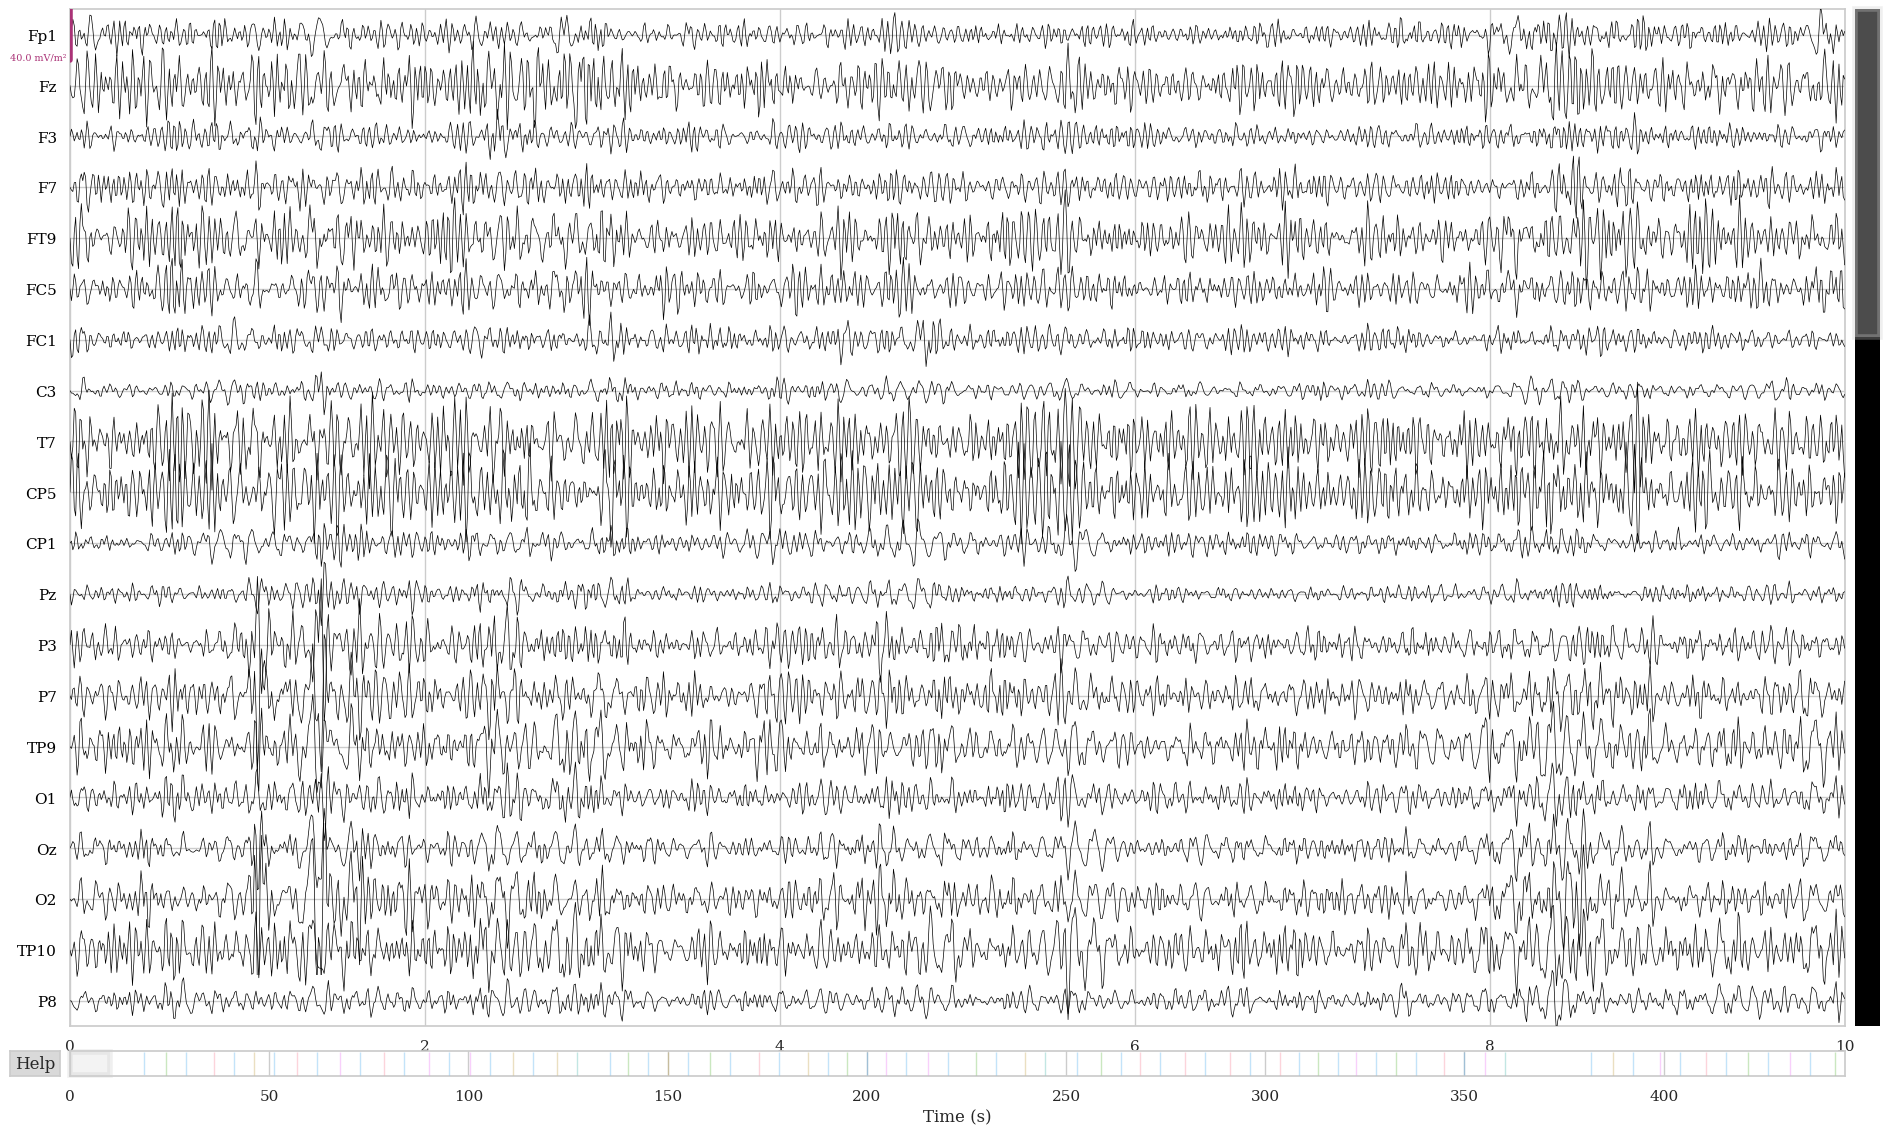

In [863]:
Raw_for_analysis = mne.preprocessing.compute_current_source_density(raw) ## Compute CSD
Raw_for_analysis = Raw_for_analysis.filter(8, 35, method='fir')
Raw_for_analysis.plot()


In [777]:
original_ann = Raw_for_analysis.annotations
event_ann = expand_triggers_to_events(original_ann,Raw_for_analysis)

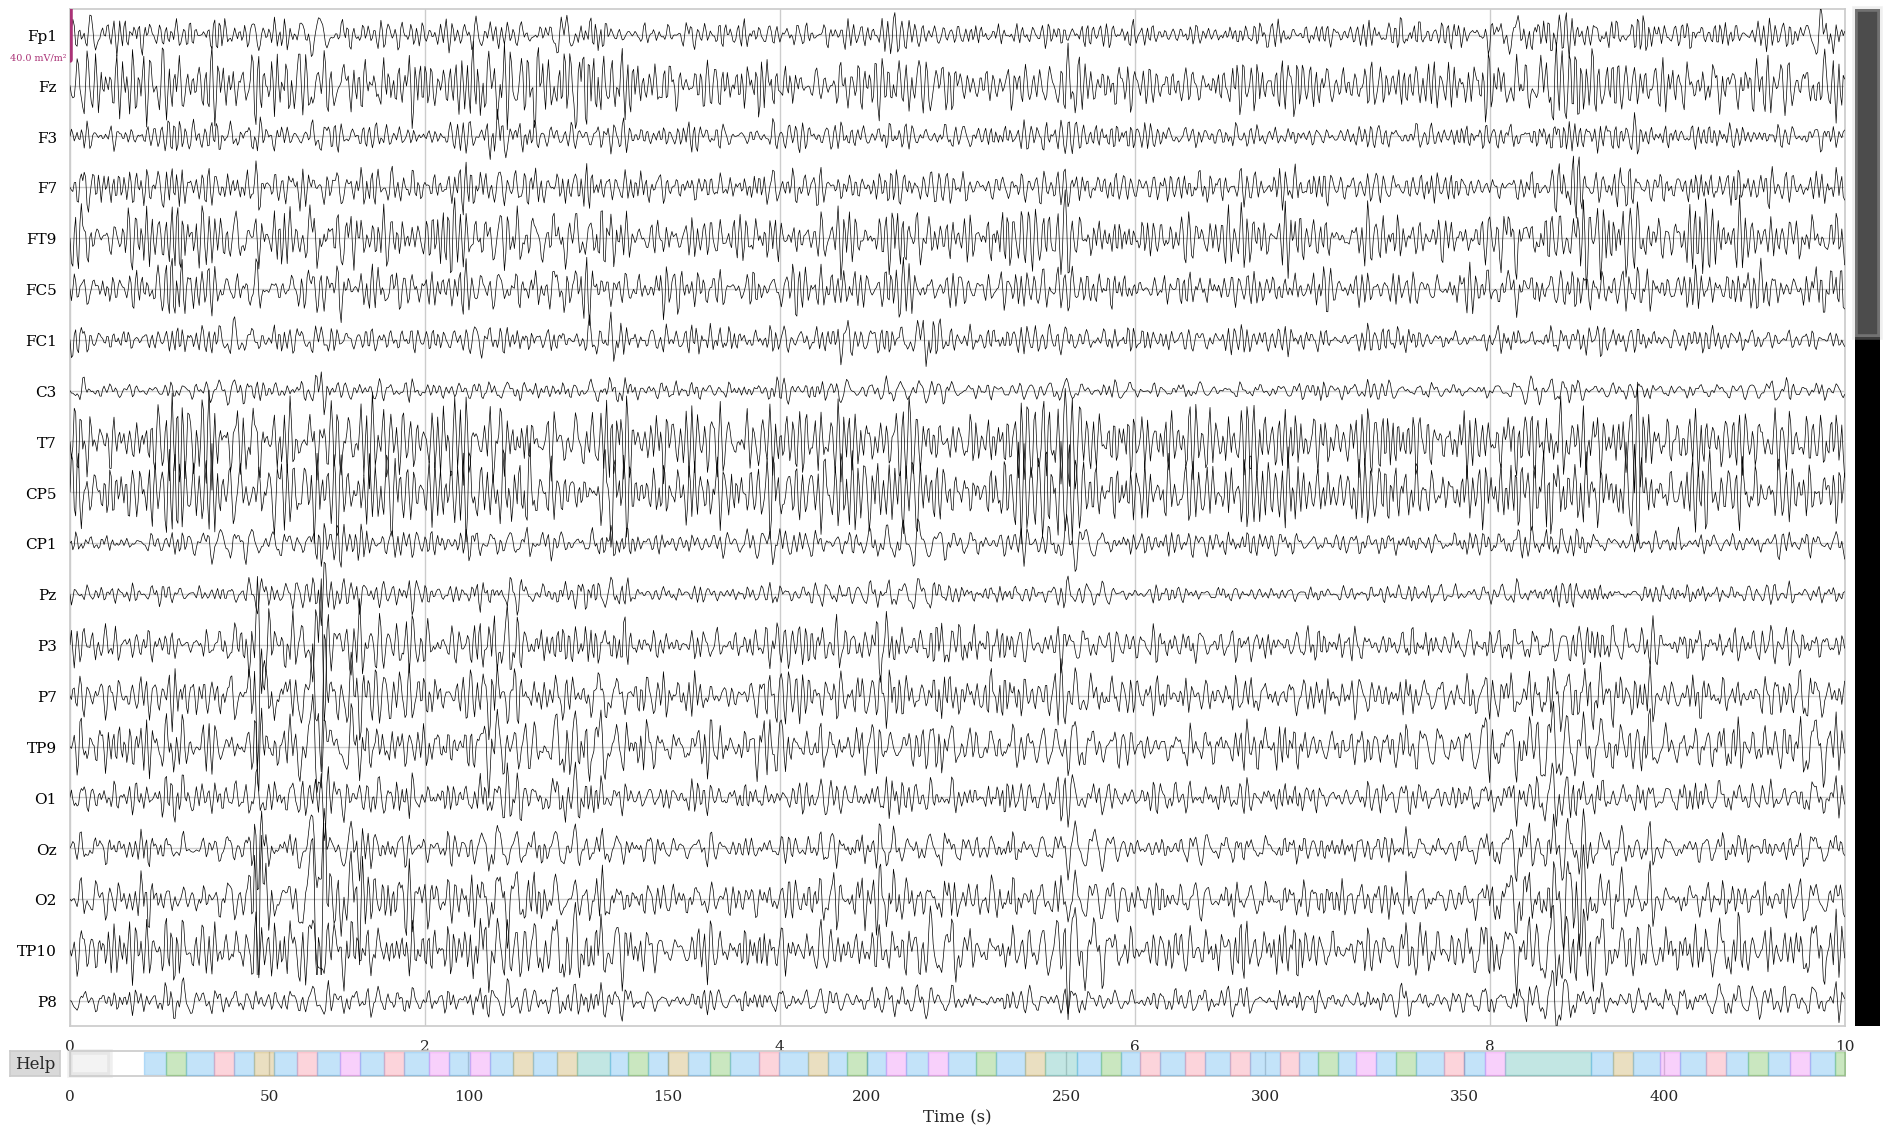

In [778]:
Raw_for_analysis.set_annotations(event_ann)

Raw_for_analysis.plot()

In [43]:
epochs

Number of events,50
Events,ClosePalm: 13Rest: 37
Time range,-8.000 – 6.000 s
Baseline,off


In [40]:
trained_clf=clf
#data_to_predict=(data_set_fb_4d_array[inds,:])
data_to_predict=epochs[:].copy().crop(tmin=1,tmax=3
                                      ).get_data()
thresholded_prediction=trained_clf.decision_function(data_to_predict)
prediction=trained_clf.predict(data_to_predict)

#note that here you can decide on which thresholds to use to better optimize your "real" usecase
#thresholded_prediction
yhat=trained_clf.predict(data_to_predict)
lr_probs = trained_clf.predict_proba(data_to_predict)

In [41]:
second_clf = trained_clf

In [203]:
# Initialize final predictions with the first classifier's predictions
final_pred = yhat.copy()

In [202]:
# The label for which we want to invoke the second classifier
# e.g., a string label or an int, depending on your y encoding
TARGET_LABEL = "motor_imagery"  # or e.g. 1

# Mask of samples where first classifier predicted the target label
mask = (yhat == TARGET_LABEL)

In [223]:
# --- SECOND LEVEL (only on masked samples) ---
if np.any(mask):
    # Run second classifier only on the subset
    data_second = data_to_predict[mask]
    second_pred = second_clf.predict(data_second)
    second_proba = second_clf.predict_proba(data_second)

    # Overwrite predictions where the second classifier was used
    final_pred[mask] = second_pred



# final_pred now contains:
# - first_clf predictions for all non-target-label samples
# - second_clf predictions for samples where first_clf predicted TARGET_LABEL

# Example: yhat, lr_probs analogs
yhat = final_pred


In [19]:
final_pred

NameError: name 'final_pred' is not defined

In [42]:
epochs

Number of events,37
Events,ClosePalm: 13LeftHand: 11RightHand: 13
Time range,-8.000 – 6.000 s
Baseline,off


In [43]:
# %%


# Function to get the list of event names for each epoch
# Function to compare actual event names with predicted event names and summarize mismatches
# Example usage:
# Assume `epochs` is your mne.Epochs object, and `predictions` is the model output

actual_events = get_epoch_events(epochs[:])  # Actual events from the epochs
predicted_events = np.array(prediction)  # Replace with your model predictions

# Compare actual events to predicted events
result = compare_events(actual_events, predicted_events)

# Output the comparison result
print(f"Accuracy: {result['accuracy']:.2f}")
if result['mismatch_details']:
    print("Mismatched epochs:")
    for mismatch in result['mismatch_details']:
        print(mismatch)
    
    print("\nMismatch Summary:")
    for mismatch_case, count in result['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches!")

Accuracy: 0.43
Mismatched epochs:
1 - LeftHand (actual), RightHand (predicted)
2 - RightHand (actual), ClosePalm (predicted)
6 - ClosePalm (actual), LeftHand (predicted)
7 - LeftHand (actual), RightHand (predicted)
8 - LeftHand (actual), RightHand (predicted)
11 - ClosePalm (actual), LeftHand (predicted)
14 - LeftHand (actual), ClosePalm (predicted)
15 - ClosePalm (actual), LeftHand (predicted)
17 - RightHand (actual), ClosePalm (predicted)
19 - LeftHand (actual), ClosePalm (predicted)
21 - LeftHand (actual), RightHand (predicted)
22 - RightHand (actual), ClosePalm (predicted)
23 - RightHand (actual), ClosePalm (predicted)
24 - RightHand (actual), ClosePalm (predicted)
26 - LeftHand (actual), ClosePalm (predicted)
28 - RightHand (actual), ClosePalm (predicted)
29 - RightHand (actual), ClosePalm (predicted)
31 - LeftHand (actual), ClosePalm (predicted)
33 - RightHand (actual), ClosePalm (predicted)
34 - LeftHand (actual), ClosePalm (predicted)
37 - LeftHand (actual), ClosePalm (predicte

In [765]:
original_ann = Raw_for_analysis.annotations

In [ ]:
raw.plot()

In [ ]:
Raw_for_analysis = raw

montage = mne.channels.read_custom_montage((f"{current_path}\Montages\CACS-64_REF.bvef"), head_size=0.095, coord_frame=None) 

Raw_for_analysis.set_montage(montage, match_case=True, match_alias=False, on_missing='raise', verbose=None)
Raw_for_analysis = mne.preprocessing.compute_current_source_density(Raw_for_analysis) ## Compute CSD
Raw_for_analysis = Raw_for_analysis.filter(0.5, 30, method='fir')
Raw_for_analysis.pick(picks)

In [ ]:
epochs

In [ ]:
thresholded_prediction

In [ ]:
def binarize_labels(labels):
    binary_mapping = {
        'ActiveRest': 0,
        'Rating': 0,
        'Rest': 0,
        'OpenPalm': 1,
        'ClosePalm': 1
    }
    return np.array([binary_mapping[label] for label in labels])


def map_labels_to_strings(binary_array):
    label_mapping = {0: "Idle", 1: "Motor Imagery"}
    return np.array([label_mapping[label] for label in binary_array])

binarized_predictions = binarize_labels(prediction)
binarized_predictions = map_labels_to_strings(binarized_predictions)

In [ ]:
# Threshold specifically for class 1:
threshold_class_1 = 18.968066
predictions = []
for sample in thresholded_prediction:
    if sample[1] >= threshold_class_1:
        predictions.append(1)
    else:
        # select the highest-scoring class between class 0 and class 2
        remaining_classes_scores = [sample[0], sample[2]]
        predicted_class = 0 if remaining_classes_scores[0] >= remaining_classes_scores[1] else 2
        predictions.append(predicted_class)

predictions = np.array(predictions)

# Output predictions
print(predictions)

In [ ]:
threshold_1 = -0.784119
threshold_2 =  -1.251891 

predictions = []
for sample in thresholded_prediction:
    class_2_score = sample[2]
    class_1_score = sample[1]
    
    if class_2_score >= threshold_2:
        predictions.append(2)
    elif class_1_score >= threshold_1:
        predictions.append(1)
    else:
        # Choose the best between remaining classes (0 and 3)
        remaining_scores = [sample[0], sample[3]]
        predicted_class = 0 if remaining_scores[0] >= remaining_scores[1] else 3
        predictions.append(predicted_class)

predictions = np.array(predictions)
print("Predicted classes:", predictions)

In [ ]:
np.set_printoptions(precision=3, suppress=True)
lr_probs

In [ ]:
# Get max probability among classes 1 and 2
max_prob_1_2 = np.max(lr_probs[:, 1:3], axis=1)

# Get the predicted class between class 1 and 2 (offset by +1)
argmax_1_2 = 1 + np.argmax(lr_probs[:, 1:3], axis=1)

# If confidence in class 1 or 2 >= 0.95 → choose that class, else → class 0
preds = np.where(
    max_prob_1_2 >= 0.5,
    argmax_1_2,
    0
)


In [ ]:
preds = np.where(
    lr_probs[:, 0] >= 0.08,
    0,
    1 + np.argmax(lr_probs[:, 1:], axis=1)
)


In [27]:

label_map = {0: 'ActiveRest', 1: 'ClosePalm', 2: 'OpenPalm',3:'Rating'}

# Assuming `preds` is your array of predictions (from the earlier logic)
label_preds = np.vectorize(label_map.get)(predictions)

print(label_preds)

NameError: name 'predictions' is not defined

In [ ]:
count = np.sum(actual_events == 'ActiveRest')
print(count)  # Output: 3

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # Added missing import
from scipy.stats import sem
from sklearn.metrics import ConfusionMatrixDisplay

# Group analysis functions moved to src/group_analysis.py and src/evaluation.py


In [102]:
# === Example: Manual per-subject runs with group aggregation ===

# Workflow:
# 1. Load a subject's data (epochs, train/val split)
# 2. Run: scores_windows, folds_cm, w_times = run_windowed_classification_aug_cv(...)
# 3. Add to group: add_subject_to_group(group_results, subject_name, scores_windows, folds_cm, w_times)
# 4. Repeat for all subjects
# 5. Plot group results: plot_accuracy_over_time_group(group_results) and plot_average_confusion_fixed_cv_group(group_results)

# Initialize fresh group results for this session
group_results = []

# Example 1: Run Subject 1 (replace with actual subject identifier)
# Assuming you have:
#   - epochs_subject1: MNE Epochs object
#   - epochs_cropped_subject1: Cropped version for training augmentation
#   - cv_split: StratifiedShuffleSplit or similar CV object
#   - params_dict: Parameter dictionary

# Example (do NOT run unless subject 1 is loaded):
'''
scores_windows_s1, folds_cm_s1, w_times_s1 = run_windowed_classification_aug_cv(
    epochs_subject1, 
    epochs_cropped_subject1, 
    cv_split, 
    params_dict, 
    BinaryClassification=False
)
add_subject_to_group(group_results, 'Subject_1', scores_windows_s1, folds_cm_s1, w_times_s1)
'''

# Example 2: Repeat for more subjects
'''
scores_windows_s2, folds_cm_s2, w_times_s2 = run_windowed_classification_aug_cv(...)
add_subject_to_group(group_results, 'Subject_2', scores_windows_s2, folds_cm_s2, w_times_s2)
'''

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'group_results.json')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")


Group results collected for 0 subjects:
✓ Saved 0 subjects to c:\Users\CensorLab\3rd_arm_MI\group_results.json
No subjects with scores_windows available.
No confusion matrices found in group_results.
✓ Group analysis complete!


In [204]:
group_results

[{'subject_name': 'GS',
  'timestamp': '2026-02-08T12:16:26.881506',
  'scores_windows': [[0.10526315789473684,
    0.10526315789473684,
    0.10526315789473684,
    0.10526315789473684,
    0.10526315789473684,
    0.10526315789473684,
    0.15789473684210525,
    0.21052631578947367,
    0.2631578947368421,
    0.21052631578947367,
    0.21052631578947367,
    0.3157894736842105,
    0.3157894736842105,
    0.2631578947368421,
    0.3157894736842105,
    0.2631578947368421,
    0.3684210526315789,
    0.47368421052631576,
    0.5263157894736842,
    0.631578947368421,
    0.8421052631578947,
    0.9473684210526315,
    0.8947368421052632,
    0.8421052631578947,
    0.7894736842105263,
    0.8421052631578947,
    0.7894736842105263,
    0.7894736842105263,
    0.7894736842105263,
    0.7368421052631579,
    0.6842105263157895,
    0.6842105263157895,
    0.631578947368421,
    0.631578947368421,
    0.5789473684210527,
    0.5263157894736842,
    0.42105263157894735],
   [0.157894736

## Multi-Subject Analysis: Run and Aggregate Performance

In [266]:
# ===================================================================
# MULTI-SUBJECT PERFORMANCE TRACKING AND AGGREGATION SYSTEM
# ===================================================================

import json
from datetime import datetime

# Group analysis functions moved to src/group_analysis.py and src/evaluation.py
# Initialize the tracker
performance_tracker = SubjectPerformanceTracker()
print("✓ Performance tracker initialized")

✓ Performance tracker initialized


In [289]:
# Group analysis functions moved to src/group_analysis.py and src/evaluation.py


In [290]:
def process_single_subject(subject_name, xdf_file_pattern, params_dict_base, verbose=True):
    """
    Complete pipeline to process a single subject end-to-end.
    
    Parameters:
    - subject_name: str, name to identify the subject
    - xdf_file_pattern: str or list, pattern to match subject files (e.g., 'Tomer')
    - params_dict_base: dict, base parameters to use (will be copied)
    - verbose: bool, whether to print progress
    
    Returns:
    - result_dict: dict containing {
        'subject_name': str,
        'epochs': MNE Epochs,
        'classifier': trained model,
        'predictions': np.array,
        'y_true': np.array,
        'metrics': dict with performance scores,
        'confusion_matrices': list of confusion matrices per window
    }
    """
    print(f"\n{'='*70}")
    print(f"Processing Subject: {subject_name.upper()}")
    print(f"{'='*70}\n")
    
    # Copy params to avoid modifying the base dict
    params = copy.deepcopy(params_dict_base)
    
    try:
        # ---- LOAD & PREPROCESS ----
        if verbose:
            print(f"[1/6] Loading and preprocessing XDF files for {subject_name}...")
        
        # Get XDF files for this subject
        xdf_files = [f for f in recording_path.glob('*.xdf') if xdf_file_pattern in f.name]
        
        if not xdf_files:
            print(f"❌ No XDF files found matching pattern: {xdf_file_pattern}")
            return None
        
        # Process all XDF files for this subject
        epochs_list = []
        for xdf_file in xdf_files:
            raw = read_raw_xdf(xdf_file)
            filtered_raw, epoch, filter_bank_epochs, _, _ = EEG_Preprocessing(current_path, raw, params)
            epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params['desired_events'])
            params['events_trigger_dict'] = {event: standard_event_id[event] for event in params['desired_events']}
            epochs_list.append(epoch)
        
        epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
        if verbose:
            print(f"   ✓ Loaded {len(epochs)} epochs")
        
        # ---- BALANCE & SPLIT ----
        if verbose:
            print(f"[2/6] Balancing and splitting data...")
        
        balanced_epochs = balance_epochs_by_subsampling(epochs, class_to_subsample='Rest')
        epochs = balanced_epochs
        
        events = epochs.events
        event_dict = epochs.event_id
        params['events_trigger_dict'] = {key: event_dict[key] for key in event_dict.keys() if key in params['desired_events']}
        
        train_inds, validation_inds, _ = Split_training_validation(epochs, None, params['events_trigger_dict'])
        epochs_copy = epochs.copy()
        returned_dict = crop_the_data(epochs_copy, train_inds, validation_inds, 
                                      params['classifier_window_s'], params['classifier_window_e'], 
                                      use_all_for_training=False)
        
        train_set_data = returned_dict['train_set_data']
        train_set_labels = returned_dict['train_set_labels']
        validation_set_data = returned_dict['validation_set_data']
        validation_set_labels = returned_dict['validation_set_labels']
        
        if verbose:
            print(f"   ✓ Train set: {len(train_set_labels)} samples")
            print(f"   ✓ Validation set: {len(validation_set_labels)} samples")
        
        # ---- AUGMENT DATA ----
        if verbose:
            print(f"[3/6] Augmenting training data...")
        
        augmented_x, augmented_y = augment_and_oversample_data_v4(
            train_set_data, train_set_labels, params['augmentation_params']
        )
        
        if verbose:
            print(f"   ✓ Augmented to {len(augmented_y)} samples")
        
        # ---- TRAIN CLASSIFIER ----
        if verbose:
            print(f"[4/6] Training classifier...")
        
        clf, csp, lda = classifier_training(augmented_x, augmented_y, params, BinaryClassification=False)
        
        if verbose:
            print(f"   ✓ Classifier trained")
        
        # ---- MAKE PREDICTIONS ----
        if verbose:
            print(f"[5/6] Making predictions on validation set...")
        
        # Get predictions on validation data
        y_pred = clf.predict(validation_set_data)
        y_true = validation_set_labels
        
        if verbose:
            print(f"   ✓ Predictions made")
        
        # ---- EVALUATE ----
        if verbose:
            print(f"[6/6] Computing performance metrics...")
        
        metrics = calculate_performance_metrics(y_true, y_pred)
        
        if verbose:
            print(f"   ✓ Accuracy: {metrics['accuracy']:.4f}")
            print(f"   ✓ F1 Score: {metrics['f1_score']:.4f}")
            print(f"   ✓ Precision: {metrics['precision']:.4f}")
            print(f"   ✓ Recall: {metrics['recall']:.4f}")
        
        result = {
            'subject_name': subject_name,
            'epochs': epochs,
            'classifier': clf,
            'predictions': y_pred,
            'y_true': y_true,
            'metrics': metrics,
            'train_inds': train_inds,
            'validation_inds': validation_inds
        }
        
        print(f"\n✓ {subject_name.upper()} processing complete!\n")
        return result
    
    except Exception as e:
        print(f"\n❌ Error processing {subject_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

In [291]:
def run_group_analysis(subject_list, params_dict_base, performance_tracker, save_results=True):
    """
    Run the complete analysis pipeline for a group of subjects.
    
    Parameters:
    - subject_list: list of dicts with keys:
        * 'name': str, subject identifier
        * 'xdf_pattern': str, pattern to match XDF files for this subject
    - params_dict_base: dict, base parameters for all subjects
    - performance_tracker: SubjectPerformanceTracker instance
    - save_results: bool, whether to save results to file
    
    Returns:
    - all_results: list of result dicts (one per subject)
    """
    
    all_results = []
    
    print("\n" + "🔬 "*30)
    print("STARTING GROUP ANALYSIS")
    print(f"Running analysis for {len(subject_list)} subjects")
    print("🔬 "*30 + "\n")
    
    for i, subject_info in enumerate(subject_list, 1):
        subject_name = subject_info['name']
        xdf_pattern = subject_info['xdf_pattern']
        
        print(f"\n[Subject {i}/{len(subject_list)}] Processing {subject_name}...")
        
        result = process_single_subject(subject_name, xdf_pattern, params_dict_base)
        
        if result is not None:
            all_results.append(result)
            
            # Add to tracker
            performance_tracker.add_subject(subject_name, result['metrics'])
        else:
            print(f"⚠️  Skipping {subject_name} due to errors\n")
    
    # Compute group statistics
    print("\n" + "="*70)
    print("COMPUTING GROUP STATISTICS...")
    print("="*70)
    
    performance_tracker.compute_group_statistics()
    performance_tracker.print_summary()
    
    # Save results
    if save_results:
        performance_tracker.save_results()
    
    return all_results


# Example: Define your subject list
# subject_list = [
#     {'name': 'Tomer', 'xdf_pattern': 'Tomer'},
#     {'name': 'Noam', 'xdf_pattern': 'Noam'},
#     {'name': 'Subject3', 'xdf_pattern': 'Subject3'}
# ]

# Run the analysis
# all_subject_results = run_group_analysis(subject_list, params_dict, performance_tracker)

In [292]:
def plot_group_performance_comparison(performance_tracker):
    """
    Create visualizations comparing performance across subjects.
    """
    df = performance_tracker.get_dataframe()
    
    if df.empty:
        print("No data to plot!")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Group Performance Comparison', fontsize=16, fontweight='bold')
    
    # Accuracy
    ax = axes[0, 0]
    bars = ax.bar(df['subject'], df['accuracy'], color='steelblue', alpha=0.8, edgecolor='black')
    ax.axhline(y=df['accuracy'].mean(), color='red', linestyle='--', label='Mean', linewidth=2)
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Accuracy by Subject', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # F1 Score
    ax = axes[0, 1]
    bars = ax.bar(df['subject'], df['f1_score'], color='darkorange', alpha=0.8, edgecolor='black')
    ax.axhline(y=df['f1_score'].mean(), color='red', linestyle='--', label='Mean', linewidth=2)
    ax.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
    ax.set_title('F1 Score by Subject', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Precision
    ax = axes[1, 0]
    bars = ax.bar(df['subject'], df['precision'], color='seagreen', alpha=0.8, edgecolor='black')
    ax.axhline(y=df['precision'].mean(), color='red', linestyle='--', label='Mean', linewidth=2)
    ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
    ax.set_title('Precision by Subject', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Recall
    ax = axes[1, 1]
    bars = ax.bar(df['subject'], df['recall'], color='crimson', alpha=0.8, edgecolor='black')
    ax.axhline(y=df['recall'].mean(), color='blue', linestyle='--', label='Mean', linewidth=2)
    ax.set_ylabel('Recall', fontsize=11, fontweight='bold')
    ax.set_title('Recall by Subject', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes


def export_group_results_to_csv(performance_tracker, filename='group_performance_summary.csv'):
    """
    Export group results to CSV for further analysis.
    """
    df = performance_tracker.get_dataframe()
    
    # Add group statistics as a row
    if performance_tracker.group_stats:
        stats_row = {
            'subject': 'GROUP_MEAN',
            'accuracy': performance_tracker.group_stats['accuracy']['mean'],
            'f1_score': performance_tracker.group_stats['f1_score']['mean'],
            'precision': np.nan,
            'recall': np.nan,
            'epochs': performance_tracker.group_stats['total_epochs']
        }
        df = pd.concat([df, pd.DataFrame([stats_row])], ignore_index=True)
    
    filepath = current_path / filename
    df.to_csv(filepath, index=False)
    print(f"✓ Results exported to {filepath}")
    
    return df

In [271]:
## Example: Running Multi-Subject Analysis

# Define parameters for your group analysis
group_subject_list = [
    {'name': 'Tomer', 'xdf_pattern': 'Tomer'},
    # Add more subjects as needed:
    # {'name': 'Noam', 'xdf_pattern': 'Noam'},
    # {'name': 'Subject3', 'xdf_pattern': 'Subject3'},
]

# Use the base params_dict (defined earlier) for consistency
base_params = copy.deepcopy(params_dict)

# Create a fresh performance tracker for this run
group_tracker = SubjectPerformanceTracker(save_path=current_path / 'group_results.json')

# Run the analysis for all subjects
# all_subject_results = run_group_analysis(
#     group_subject_list, 
#     base_params, 
#     group_tracker,
#     save_results=True
# )

print("Example setup complete. Uncomment the run_group_analysis call above to start processing.")
print("\nTo use this system:")
print("1. Update 'group_subject_list' with your subjects")
print("2. Uncomment the run_group_analysis() call")
print("3. View results with: group_tracker.print_summary()")
print("4. Visualize with: plot_group_performance_comparison(group_tracker)")
print("5. Export CSV with: export_group_results_to_csv(group_tracker)")

Example setup complete. Uncomment the run_group_analysis call above to start processing.

To use this system:
1. Update 'group_subject_list' with your subjects
2. Uncomment the run_group_analysis() call
3. View results with: group_tracker.print_summary()
4. Visualize with: plot_group_performance_comparison(group_tracker)
5. Export CSV with: export_group_results_to_csv(group_tracker)


In [295]:
export_group_results_to_csv(group_tracker)

✓ Results exported to c:\Users\CensorLab\3rd_arm_MI\group_performance_summary.csv


""


In [294]:
## Utilities for Accessing Group Results

# Group analysis functions moved to src/group_analysis.py and src/evaluation.py
def get_subject_result(all_results, subject_name):
    """
    Retrieve a specific subject's result from all_results list.
    
    Parameters:
    - all_results: list of result dicts from run_group_analysis()
    - subject_name: str, name of subject to retrieve
    
    Returns:
    - result dict for that subject, or None if not found
    """
    for result in all_results:
        if result['subject_name'].lower() == subject_name.lower():
            return result
    return None


def compare_two_subjects(all_results, subject1_name, subject2_name):
    """
    Compare performance metrics between two subjects.
    """
    subject1 = get_subject_result(all_results, subject1_name)
    subject2 = get_subject_result(all_results, subject2_name)
    
    if subject1 is None or subject2 is None:
        print("❌ One or both subjects not found!")
        return
    
    print(f"\n{'='*60}")
    print(f"COMPARISON: {subject1_name} vs {subject2_name}")
    print(f"{'='*60}")
    
    metrics1 = subject1['metrics']
    metrics2 = subject2['metrics']
    
    print(f"\n{'Metric':<15} {subject1_name:>15} {subject2_name:>15} {'Difference':>12}")
    print("-" * 60)
    
    for key in ['accuracy', 'f1_score', 'precision', 'recall']:
        val1 = metrics1.get(key, np.nan)
        val2 = metrics2.get(key, np.nan)
        diff = val1 - val2
        winner = "👉 " if abs(diff) > 0.01 else "  "
        print(f"{key:<15} {val1:>15.4f} {val2:>15.4f} {diff:>11.4f} {winner}")


def create_individual_subject_report(result, save_path=None):
    """
    Create a detailed report for a single subject including visualizations.
    """
    subject_name = result['subject_name']
    metrics = result['metrics']
    
    if save_path is None:
        save_path = current_path / f'{subject_name}_report.txt'
    
    report_text = f"""
{'='*70}
INDIVIDUAL SUBJECT REPORT
{'='*70}

Subject: {subject_name}
Generated: {datetime.now().isoformat()}

PERFORMANCE METRICS:
--------------------
Accuracy:  {metrics.get('accuracy', 'N/A'):.4f}
F1 Score:  {metrics.get('f1_score', 'N/A'):.4f}
Precision: {metrics.get('precision', 'N/A'):.4f}
Recall:    {metrics.get('recall', 'N/A'):.4f}
Total Epochs: {metrics.get('epochs', 'N/A')}

CONFUSION MATRIX:
-----------------
{metrics.get('confusion_matrix', 'N/A')}

{'='*70}
"""
    
    with open(save_path, 'w') as f:
        f.write(report_text)
    
    print(f"✓ Report saved to {save_path}")
    print(report_text)

## Quick Reference Guide for Multi-Subject Analysis

### Basic Workflow

1. **Initialize the system** (done above)
   ```python
   performance_tracker = SubjectPerformanceTracker()
   ```

2. **Define your subject list**
   ```python
   subject_list = [
       {'name': 'SubjectA', 'xdf_pattern': 'SubjectA'},
       {'name': 'SubjectB', 'xdf_pattern': 'SubjectB'},
   ]
   ```

3. **Run the analysis**
   ```python
   all_results = run_group_analysis(
       subject_list, 
       params_dict,  # Use your base parameters
       performance_tracker
   )
   ```

4. **View results**
   ```python
   performance_tracker.print_summary()  # Print statistics
   plot_group_performance_comparison(performance_tracker)  # Visualize
   export_group_results_to_csv(performance_tracker)  # Export
   ```

### Key Functions

- **`SubjectPerformanceTracker`** - Main class for tracking and aggregating results
- **`process_single_subject()`** - Process one subject end-to-end
- **`run_group_analysis()`** - Orchestrate multi-subject processing
- **`calculate_performance_metrics()`** - Compute metrics from predictions
- **`plot_group_performance_comparison()`** - Visualize group comparisons
- **`export_group_results_to_csv()`** - Save results to CSV
- **`get_subject_result()`** - Retrieve individual subject result
- **`compare_two_subjects()`** - Side-by-side comparison
- **`create_individual_subject_report()`** - Generate subject report

### Output Files

When you run the analysis, these files are created:
- **`group_results.json`** - Complete results and statistics in JSON format
- **`group_performance_summary.csv`** - Summary metrics in CSV format
- **`{subject}_report.txt`** - Individual subject reports (optional)

### Accessing Results After Analysis

```python
# Get group statistics
stats = performance_tracker.group_stats

# Get as DataFrame for analysis
df = performance_tracker.get_dataframe()

# Retrieve a specific subject's data
subject_result = get_subject_result(all_results, 'SubjectA')

# Compare two subjects
compare_two_subjects(all_results, 'SubjectA', 'SubjectB')

# Load previously saved results
results = load_group_results()
```

In [30]:
fname = 'NC_Raw_for_analysis_290126'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Raw_for_analysis, picklefile)
#close the file
picklefile.close()

# === Saving ===
ann_fname = current_path / 'Models' / 'JE_ann_210126'
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)
# === Saving ===
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)



NameError: name 'Raw_for_analysis' is not defined

Save the trained model 


In [ ]:

# Example: Plot confusion matrix for the first time window
conf_matrix, class_labels = confusion_matrices_per_window[41]
plot_confusion_matrix(conf_matrix, class_labels)

In [ ]:
scores_per_time_window


In [ ]:
def average_from_index_to_index(lst, start, end):
    # Ensure the indices are within the bounds of the list
    if start < 0 or end >= len(lst) or start > end:
        raise ValueError("Invalid start or end index")
    
    # Slice the list from start to end (inclusive)
    sublist = lst[start:end+1]
    
    # Calculate the average
    average = sum(sublist) / len(sublist)
    
    return average

# Example usage
start_index = 40
end_index =70
print(average_from_index_to_index(scores_per_time_window, start_index, end_index))  # Output: 35.0

In [ ]:
# Time points (assuming each point is 100 ms apart)
time_points = np.arange(0, len(scores_per_time_window) * 0.1, 0.1)  # in seconds

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(time_points, scores_per_time_window, marker='o')
plt.title('Sliding Window Scores Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Score')
plt.grid(True)
plt.show()

In [ ]:
all_epoch_data = epochs.get_data()

In [ ]:

scaler = RobustScaler()
all_epoch_data_flat = all_epoch_data.reshape(all_epoch_data.shape[0], -1)
all_epoch_data_normalized = scaler.fit_transform(all_epoch_data_flat).reshape(all_epoch_data.shape)

# Update combined epochs with normalized data
epochs._data = all_epoch_data_normalized

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler


In [ ]:
loaded_epochs = mne.read_epochs('epochs_combined-epo2.fif', preload=True)

In [ ]:


def prepare_noise_epochs(raw, params_dict, reference_epochs=None, apply_csd=False, center_noise=False):
    """
    Create realistic noise epochs from the first 54s of a raw EEG recording.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        The raw EEG recording.
    params_dict : dict
        Dictionary containing 'epoch_tmin', 'epoch_tmax', 'bad_electrodes', etc.
    reference_epochs : mne.Epochs (optional)
        If provided, picks channel names from this object to match real epochs.
    apply_csd : bool
        Whether to apply Current Source Density (CSD) to noise epochs.
    center_noise : bool
        Whether to apply global mean-centering to the noise epochs.
    
    Returns:
    --------
    noise_epochs : mne.Epochs
        Preprocessed EpochsArray labeled as 'noise'.
    """
    #extract the current run paramaters: 
    apply_csd=params_dict['PerformCsd']
    LowPass, HighPass, filter_method = params_dict['LowPass'],params_dict['HighPass'],params_dict['filter_method']
    tmin=params_dict['epoch_tmin']
    tmax=params_dict['epoch_tmax']
    
    sfreq = raw.info['sfreq']
    tmin = params_dict['epoch_tmin']
    tmax = params_dict['epoch_tmax']
    epoch_length = tmax - tmin
    step_size = 2.0  # Use 80% overlap for more noise epochs

    # 1. Crop raw to 0–54s (safe margin for -tmin and +tmax)
    raw_noise = raw.copy().crop(tmin=4.0, tmax=54.0 - tmax)

    #remove non existent channels: 
    if 'ACC_X' in raw_noise.ch_names:
        raw_noise.drop_channels(['ACC_X','ACC_Y','ACC_Z']) ## Drop non eeg channels
    #set the correct (Brainvision Montage) montage:
    montage = mne.channels.read_custom_montage((f"{current_path}\Montages\CACS-64_REF.bvef"), head_size=0.095, coord_frame=None) 
    #rename channels for consistency (no longer required for future recordings): 
    #mne.rename_channels(Raw.info, {'F9' : 'FT9','P9' : 'TP9','P10' : 'TP10','F10' : 'FT10','AF1' : 'AF7' }, allow_duplicates=False, verbose=None)
    raw_noise.set_montage(montage, match_case=True, match_alias=False, on_missing='raise', verbose=None)

    # 2. Generate overlapping fake events
    noise_events = mne.make_fixed_length_events(raw_noise, duration=step_size)
    valid_events = []
    for event in noise_events:
        event_time = event[0] / sfreq
        if event_time - abs(tmin) >= 0 and event_time + tmax <= 54:
            event[2] = 99  # set event code to 'noise'
            valid_events.append(event)
    valid_events = np.array(valid_events)

    if len(valid_events) == 0:
        raise ValueError("No valid noise epochs found. Check time window and overlap settings.")
    curr_elecs_in_epochs_set=set(raw_noise.info['ch_names'])
    elecs_to_remove=params_dict['bad_electrodes']
    elecs_to_drop=curr_elecs_in_epochs_set.intersection(elecs_to_remove)
    filtered_electrodes  = [elec for elec in params_dict['Electorde_Group'] if elec not in elecs_to_drop]
    selected_elecs=filtered_electrodes
    if len(elecs_to_drop)>0: 
        raw_noise.drop_channels(list(elecs_to_drop))
    raw_noise.drop_channels(raw_noise.info['bads'])
    raw_noise.set_eeg_reference(ref_channels="average")
    mne.set_eeg_reference(raw_noise, copy=False)
    print('\n###########################################################')
    print('filtering the data')  
    unfiltered_Raw=raw_noise.copy()
    Raw_Filtered = unfiltered_Raw.filter(LowPass, HighPass, method=filter_method, pad='reflect_limited')

    # 3. Create MNE Epochs
    noise_epochs = mne.Epochs(
        Raw_Filtered,
        events=valid_events,
        event_id={'noise': 99},
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True
    )

    # 4. Drop bad channels
    bads = set(params_dict['bad_electrodes']).intersection(set(noise_epochs.info['ch_names']))
    if bads:
        noise_epochs.drop_channels(list(bads))

    # 5. Match channel order to reference_epochs (if provided)
    if reference_epochs is not None:
        noise_epochs.pick_channels(reference_epochs.ch_names)

    # 6. Apply CSD if requested
    if apply_csd:
        noise_epochs = mne.preprocessing.compute_current_source_density(noise_epochs)
    noise_epochs.pick(selected_elecs)
    # 7. Apply global mean-centering if requested
    if center_noise:
        data = noise_epochs.get_data()
        mean = data.mean(axis=0)
        centered_data = data - mean
        noise_epochs = mne.EpochsArray(centered_data, noise_epochs.info,
                                       events=noise_epochs.events,
                                       event_id=noise_epochs.event_id,
                                       tmin=noise_epochs.tmin)

    return noise_epochs


In [ ]:

# Create noise epochs
noise_epochs = prepare_noise_epochs(
    raw=raw,
    params_dict=params_dict,
    reference_epochs=epochs,
    apply_csd=params_dict['PerformCsd'],
    center_noise=False  # or True, if you want to match structure
)

# Combine
combined_epochs = mne.concatenate_epochs([epochs, noise_epochs])
X = combined_epochs.get_data()
y = combined_epochs.events[:, 2]


In [ ]:
combined_epochs = mne.concatenate_epochs([epochs, noise_epochs])


In [8]:
# %%
from mne.stats import permutation_cluster_1samp_test as pcluster_test
from mne.time_frequency import tfr_multitaper,tfr_morlet
from matplotlib.colors import TwoSlopeNorm
# ERD Maps Section
freqs = np.arange(2, 35)  # frequencies from 2-35Hz
# vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = (-2, 0)  # baseline interval (in s)
# cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test
n_cycles = np.linspace(2.6, 2.6 + 0.2 * (30 - 1), len(freqs))
tfr = tfr_multitaper(
    epochs.pick(["C3","Cz","C4"]),
    freqs=freqs,
    n_cycles=freqs,
    use_fft=True,
    return_itc=False,
    average=False,
    decim=2,
)
mode = 'zscore'  # alternatives: 'ratio', 'zscore', 'percent'
#power.apply_baseline(baseline=baseline, mode=mode)
tfr.crop(-2, 3).apply_baseline(baseline, mode=mode)
tfr.average().plot()

for event in params_dict['desired_events']:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(
        1, 4, figsize=(12, 4), gridspec_kw={"width_ratios": [10, 10, 10, 1]}
    )
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch],
            cmap="RdBu",
            axes=ax,
            colorbar=False,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")
    fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()
# %%



NameError: name 'epochs' is not defined

In [10]:
band_dict =  dict(Alpha=dict(fmin=8, fmax=12),
                    Beta=dict(fmin=15, fmax=28))
tfr = tfr_multitaper(
    epochs,
    freqs=freqs,
    n_cycles=freqs,
    use_fft=True,
    return_itc=False,
    average=False,
    decim=2,
)

tfr.crop(-3, 5).apply_baseline(baseline, mode="zscore")


for title,fmin_fmax in band_dict.items():

    fig, axes = plt.subplots(1, 3, figsize=(7, 4), constrained_layout=True)
    fig.suptitle(title, fontsize=16)
    
    tfr_band = tfr.copy().crop(fmin = fmin_fmax['fmin'], fmax =fmin_fmax['fmax'])

    
    plot_dict = dict(Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=15, fmax=28))

    for event in params_dict['desired_events']:
        tfr_ev = tfr[event]
        tfr_ev.average().plot_topomap(**fmin_fmax, axes=ax)
        ax.set_title(title)
        
    plt.tight_layout()
    plt.show()


NameError: name 'epochs' is not defined

In [11]:
epochs['ClosePalm']

NameError: name 'epochs' is not defined

In [ ]:
freqs = np.arange(2, 40,1)  # frequencies from 2-35Hz
vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = (-2.8, -1.8)  # baseline interval (in s)
cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test

n_cycles = freqs / 2.  # or fixed like 4


In [183]:
power = tfr_multitaper(epochs['ClosePalm'], freqs=freqs, n_cycles=n_cycles,
                       use_fft=True, return_itc=False, decim=3, n_jobs=1)
mode = 'zscore'  # alternatives: 'ratio', 'zscore', 'logratio'
power.apply_baseline(baseline=baseline, mode=mode)

Applying baseline correction (mode: zscore)


<AverageTFR | time : [-8.000000, 5.998000], freq : [2.000000, 34.000000], nave : 14, channels : 3, ~1.8 MB>

No baseline correction applied


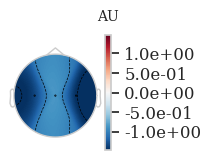

In [184]:
power.plot_topomap(
    tmin=0, tmax=2, fmin=15, fmax=30)


In [ ]:
epochs.ch_names

In [ ]:


tfr = tfr_multitaper(
    epochs.pick(["C3","Cz","C2"]),
    freqs=freqs,
    n_cycles=freqs,
    use_fft=True,
    return_itc=False,
    average=False,
    decim=2,
)

tfr.crop(-3, 5).apply_baseline(baseline, mode="percent")
tfr.average().plot()


In [ ]:


tfr = tfr_multitaper(
    epochs.pick(['C5','Cz','C6']),
    freqs=freqs,
    n_cycles=freqs,
    use_fft=True,
    return_itc=False,
    average=False,
    decim=2,
)

tfr.crop(-3, 5).apply_baseline(baseline, mode="logratio")

for event in params_dict['desired_events']:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(
        1, 4, figsize=(12, 4), gridspec_kw={"width_ratios": [10, 10, 10, 1]}
    )
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch],
            cmap="RdBu",
            cnorm=cnorm,
            axes=ax,
            colorbar=False,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")
    fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()

In [ ]:
epochs_close = epochs['ClosePalm']
epochs_open = epochs['OpenPalm']
epochs_rest = epochs['ActiveRest']


In [ ]:
from mne.time_frequency import tfr_multitaper

freqs = np.arange(0.5, 35, 1)
n_cycles = freqs / 2.  # or fixed

power_close = tfr_multitaper(epochs_close, freqs=freqs, n_cycles=n_cycles,
                             use_fft=True, return_itc=False, decim=3, n_jobs=1)
power_open = tfr_multitaper(epochs_open, freqs=freqs, n_cycles=n_cycles,
                              use_fft=True, return_itc=False, decim=3, n_jobs=1)
power_rest = tfr_multitaper(epochs_rest, freqs=freqs, n_cycles=n_cycles,
                             use_fft=True, return_itc=False, decim=3, n_jobs=1)


In [ ]:
baseline = (-2.8, -1.8)
mode = 'zscore'  # or 'percent'

for power in [power_close, power_open, power_rest]:
    power.apply_baseline(baseline=baseline, mode=mode)


In [ ]:
avg_power_close = power_close.data.mean(axis=0)  # shape: freqs × times
avg_power_open = power_open.data.mean(axis=0)
avg_power_rest = power_rest.data.mean(axis=0)


In [ ]:
import matplotlib.pyplot as plt
times = power_close.times

plt.figure(figsize=(10, 5))
plt.imshow(avg_power_close, aspect='auto', origin='lower',
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap='RdBu_r', vmin=-1.5, vmax=1.5)
plt.colorbar(label='ERD/ERS (log ratio)')
plt.title('close MI – Average ERD/ERS')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()


In [ ]:
times = power_rest.times

plt.figure(figsize=(10, 5))
plt.imshow(avg_power_rest, aspect='auto', origin='lower',
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap='RdBu_r', vmin=-1.5, vmax=1.5)
plt.colorbar(label='ERD/ERS (log ratio)')
plt.title('rest – Average ERD/ERS')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

In [ ]:
times = power_open.times

plt.figure(figsize=(10, 5))
plt.imshow(avg_power_open, aspect='auto', origin='lower',
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap='RdBu_r', vmin=-1.5, vmax=1.5)
plt.colorbar(label='ERD/ERS (log ratio)')
plt.title('open MI – Average ERD/ERS')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

In [ ]:
diff_power = avg_power_close - avg_power_rest


In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(diff_power, aspect='auto', origin='lower',
           extent=[times[0], times[-1], freqs[0], freqs[-1]],
           cmap='RdBu_r', vmin=-1.5, vmax=1.5)
plt.colorbar(label='ERD/ERS (log ratio)')
plt.title('diff :close-rest – Average ERD/ERS')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

In [ ]:
power_close.plot_topomap(tmin=0.5, tmax=2, fmin=0.5, fmax=35,  cmap='RdBu_r')


In [ ]:
def plot_accuracy_over_time(scores_input, w_times, params_dict=None, axes_handle=None):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import sem

    if params_dict is None:
        params_dict = {}
    if axes_handle is None:
        _, axes_handle = plt.subplots()

    num_classes = len(params_dict.get('desired_events', [0, 1, 2]))
    chance_level = 1 / num_classes

    # === Case 1: If input is already a DataFrame ===
    if isinstance(scores_input, pd.DataFrame):
        longform_df = scores_input.copy()
        if 'Time' not in longform_df.columns or 'Accuracy' not in longform_df.columns:
            raise ValueError("DataFrame must contain 'Time' and 'Accuracy' columns.")

        longform_df['Time'] = longform_df['Time'].astype(float)

        # Compute mean and sem per timepoint
        summary_df = longform_df.groupby('Time')['Accuracy'].agg(['mean', sem]).reset_index()
        summary_df.rename(columns={'mean': 'Mean', 'sem': 'SEM'}, inplace=True)

    # === Case 2: If input is a list of score arrays ===
    else:
        subjects_scores_windows = scores_input if isinstance(scores_input, list) else [scores_input]
        all_folds = []
        for subj_data in subjects_scores_windows:
            subj_data = np.squeeze(np.array(subj_data))
            if subj_data.shape[1] != len(w_times):
                raise ValueError("Mismatch between scores_windows and w_times.")
            all_folds.append(subj_data)
        all_folds_array = np.concatenate(all_folds, axis=0)

        mean_acc = np.mean(all_folds_array, axis=0)
        sem_acc = sem(all_folds_array, axis=0)
        times = np.round(w_times, 2)

        summary_df = pd.DataFrame({
            'Time': times,
            'Mean': mean_acc,
            'SEM': sem_acc
        })

    # Plot
    axes_handle.plot(summary_df['Time'], summary_df['Mean'], label='Mean Accuracy', color='#4682B4')
    axes_handle.fill_between(summary_df['Time'],
                             summary_df['Mean'] - summary_df['SEM'],
                             summary_df['Mean'] + summary_df['SEM'],
                             alpha=0.3, color='#4682B4', label='±1 SEM')

    # Onset, chance, cue
    if any(np.array(w_times) > 0):
        onset_time = np.round(np.array(w_times)[np.array(w_times) >= 0][0], 2)
        axes_handle.axvline(onset_time, linestyle='--', color='k', label='Onset')

    axes_handle.axhline(chance_level, linestyle='-.', color='gray', label=f'Chance ({chance_level:.2f})')
    axes_handle.axvspan(-1.25, 0, color='blue', alpha=0.2, label='Cue (Jittered)')

    # Style
    axes_handle.set_xlabel('Time (s)')
    axes_handle.set_ylabel('Classification Accuracy')
    axes_handle.set_title('Mean Accuracy Over Time (±SEM)')
    axes_handle.set_ylim([0.2, 1])
    axes_handle.set_xlim([-2, 5])
    axes_handle.legend(loc='lower right')
    axes_handle.grid(True)


def build_scores_df(subjects_scores_windows, w_times):
    import numpy as np
    import pandas as pd

    if not isinstance(subjects_scores_windows, list):
        subjects_scores_windows = [subjects_scores_windows]

    all_subjects_df = []

    for subj_idx, subj_data in enumerate(subjects_scores_windows):
        subj_data = np.squeeze(np.array(subj_data))  # shape (n_folds, n_times)
        if subj_data.ndim != 2:
            raise ValueError(f"Expected (n_folds, n_times), got shape {subj_data.shape} for subject {subj_idx}")
        if subj_data.shape[1] != len(w_times):
            raise ValueError(f"Mismatch between number of timepoints and w_times for subject {subj_idx}")
        
        times_col_names = [np.round(t, 2) for t in w_times]
        df = pd.DataFrame(columns=times_col_names, data=subj_data)
        df['Fold'] = range(len(df))
        df['Subject'] = f'Subject {subj_idx+1}'
        df['scores_window'] = [row for row in subj_data]  # keep raw score array for each fold

        melted = pd.melt(df, id_vars=['Fold', 'Subject', 'scores_window'], 
                         value_vars=times_col_names, var_name='Time', value_name='Accuracy')
        melted['Time'] = melted['Time'].astype(float)
        all_subjects_df.append(melted)

    scores_df = pd.concat(all_subjects_df, ignore_index=True)
    return scores_df


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
import numpy as np
import matplotlib.pyplot as plt

def plot_average_confusion_multiple_subjects_cv(
    all_subjects_folds_conf_matrices,
    window_index,
    normalize=True,
    show_f1=True,
    cmap='viridis'
):
    """
    Plot average confusion matrix across multiple subjects and CV folds.
    
    Parameters:
        all_subjects_folds_conf_matrices: list of folds_conf_matrices_per_window for each subject.
        window_index: int, list, range, or slice — selects window(s) to average over.
        normalize: if True, normalize rows to sum to 1.
        show_f1: if True, compute macro F1 score and display in title.
        cmap: matplotlib colormap string (e.g., 'viridis', 'Blues').
    """
    # Handle single or multiple window indices
    if isinstance(window_index, int):
        window_indices = [window_index]
    else:
        window_indices = list(window_index)

    all_matrices = []
    all_preds = []
    all_trues = []

    for subj_folds in all_subjects_folds_conf_matrices:
        for fold in subj_folds:
            for w_idx in window_indices:
                cm, labels = fold[w_idx]
                all_matrices.append(cm)

                # For F1 calculation, reconstruct predictions and ground truths
                y_true = np.repeat(np.arange(cm.shape[0]), cm.sum(axis=1).astype(int))
                y_pred = np.concatenate([
                    np.repeat(j, int(cm[i, j])) for i in range(cm.shape[0]) for j in range(cm.shape[1])
                ])
                all_trues.extend(y_true)
                all_preds.extend(y_pred)

    avg_matrix = np.mean(all_matrices, axis=0)

    if normalize:
        avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
        avg_matrix = np.nan_to_num(avg_matrix)

    # Compute macro F1
    macro_f1 = f1_score(all_trues, all_preds, average='macro') if show_f1 else None

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=avg_matrix, display_labels=labels)
    disp.plot(cmap=cmap, ax=ax, values_format=".2f")
    
    title = f"Avg Confusion Matrix (Windows {window_indices[0]}–{window_indices[-1]})"
    if show_f1:
        title += f" | Macro F1: {macro_f1:.2f}"
    ax.set_title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


plot_average_confusion_multiple_subjects_cv(
    [folds_conf_matrices_subj1, folds_conf_matrices_subj2],
    window_index=range(10, 20),
    normalize=True,
    show_f1=True,
    cmap='viridis'  # options: 'viridis', 'cividis', 'YlGnBu', etc.
)


In [ ]:
from scipy.stats import sem
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy_over_time_multiple_subjects(
    subjects_scores_windows,
    w_times,
    params_dict=None,
    axes_handle=None,
    tmin=None,
    tmax=None,
    cmap_main='#3B8686',  # Viridis-like teal
    cmap_sem='#79BD9A'    # Lighter green for SEM fill
):
    """
    Plot mean accuracy over time with SEM shading across multiple subjects' CV folds.
    
    Parameters:
        subjects_scores_windows: list of (n_folds, n_times) arrays
        w_times: list/array of time values
        params_dict: dict with metadata (e.g., 'desired_events' for chance level)
        axes_handle: optional matplotlib Axes
        tmin, tmax: restrict time range (e.g., -2, 4)
        cmap_main: line color
        cmap_sem: SEM fill color
    """
    if params_dict is None:
        params_dict = {}
    if axes_handle is None:
        _, axes_handle = plt.subplots()

    if not isinstance(subjects_scores_windows, list):
        subjects_scores_windows = [subjects_scores_windows]

    # Collect all folds
    all_folds = []
    for subj_data in subjects_scores_windows:
        subj_data = np.squeeze(np.array(subj_data))  # (n_folds, n_times)
        if subj_data.shape[1] != len(w_times):
            raise ValueError("Mismatch between scores_windows and w_times.")
        all_folds.append(subj_data)
    all_folds_array = np.concatenate(all_folds, axis=0)

    # Crop times
    times = np.array(w_times)
    if tmin is not None or tmax is not None:
        mask = np.ones_like(times, dtype=bool)
        if tmin is not None:
            mask &= times >= tmin
        if tmax is not None:
            mask &= times <= tmax
        times = times[mask]
        all_folds_array = all_folds_array[:, mask]

    # Compute stats
    mean_acc = np.mean(all_folds_array, axis=0)
    sem_acc = sem(all_folds_array, axis=0)

    # Plot
    axes_handle.plot(times, mean_acc, label='Mean Accuracy', color=cmap_main, linewidth=2)
    axes_handle.fill_between(times, mean_acc - sem_acc, mean_acc + sem_acc,
                             alpha=0.3, color=cmap_sem, label='±1 SEM')

    # Onset, cue, and chance markers
    if np.any(times >= 0):
        axes_handle.axvline(times[times >= 0][0], linestyle='--', color='k', label='Onset')

    if 'desired_events' in params_dict:
        chance_level = 1 / len(params_dict['desired_events'])
        axes_handle.axhline(chance_level, linestyle='-.', color='gray',
                            label=f'Chance ({chance_level:.2f})')

    axes_handle.axvspan(-1.25, 0, color='cornflowerblue', alpha=0.2, label='Cue')

    # Styling
    axes_handle.set_xlabel('Time (s)', fontsize=14)
    axes_handle.set_ylabel('Accuracy', fontsize=14)
    axes_handle.set_title('Accuracy Over Time Across Subjects (±SEM)', fontsize=16)
    axes_handle.set_xlim([times.min(), times.max()])
    axes_handle.set_ylim([0.2, 1])
    axes_handle.tick_params(labelsize=12)
    axes_handle.legend(loc='lower right', fontsize=11)
    axes_handle.grid(True)
    plt.tight_layout()


In [ ]:

def plot_accuracy_over_time(scores_windows, w_times, params_dict=None, axes_handle=None,
                             tmin_display=None, tmax_display=None):
    """
    Plot classification accuracy over time for a single subject.

    Parameters:
        scores_windows (list or np.ndarray): Accuracy scores per fold per time window.
        w_times (list or np.ndarray): Center times of each window.
        params_dict (dict): Must contain 'desired_events' for chance level calculation.
        axes_handle (matplotlib axis): Optional axis to plot on.
        tmin_display (float): Minimum time to show on x-axis.
        tmax_display (float): Maximum time to show on x-axis.
    """
    if params_dict is None:
        params_dict = {}
    if axes_handle is None:
        _, axes_handle = plt.subplots()

    # Wrap in array and validate
    scores_windows = np.squeeze(np.array(scores_windows))
    if scores_windows.shape[1] != len(w_times):
        raise ValueError("Mismatch between scores_windows columns and w_times length.")

    num_classes = len(params_dict.get('desired_events', []))
    chance_level = 1 / num_classes if num_classes > 0 else 0.33

    # Format into DataFrame
    col_times = np.round(w_times, 2)
    scores_df = pd.DataFrame(scores_windows, columns=col_times)
    scores_df['fold_id'] = range(len(scores_df))
    longform_df = pd.melt(scores_df, id_vars='fold_id', var_name='Time', value_name='Accuracy')
    longform_df['Time'] = longform_df['Time'].astype(float)

    # Plot
    sns.lineplot(data=longform_df, x='Time', y='Accuracy', ax=axes_handle, color='teal')

    # Onset and cue markers
    if any(w_times > 0):
        onset = np.round(np.array(w_times)[np.array(w_times) >= 0][0], 2)
        axes_handle.axvline(onset, linestyle='--', color='k', label='Onset')
    axes_handle.axvspan(-1.25, 0, color='cornflowerblue', alpha=0.25, label='Cue')

    # Horizontal chance line
    axes_handle.axhline(chance_level, linestyle='-.', color='gray', label=f'Chance ({chance_level:.2f})')

    # Style
    axes_handle.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
    axes_handle.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
    axes_handle.set_title('Accuracy Over Time (Single Subject)', fontsize=16, fontweight='bold')
    axes_handle.set_ylim([0.2, 1])
    axes_handle.set_xlim([tmin_display if tmin_display is not None else -2,
                          tmax_display if tmax_display is not None else 5])
    axes_handle.legend(loc='lower right')
    axes_handle.grid(True)

def plot_accuracy_over_time_multiple_subjects(subjects_scores_windows, w_times, params_dict=None, axes_handle=None,
                                              tmin_display=None, tmax_display=None):
    """
    Plot mean classification accuracy over time (±STD) across multiple subjects.

    Parameters:
        subjects_scores_windows (list of arrays): Each item = (n_folds, n_times) array per subject.
        w_times (list or np.ndarray): Center times of each window.
        params_dict (dict): Must contain 'desired_events' for chance level.
        axes_handle (matplotlib axis): Optional axis to plot on.
        tmin_display (float): Minimum time to show on x-axis.
        tmax_display (float): Maximum time to show on x-axis.
    """
    if params_dict is None:
        params_dict = {}
    if axes_handle is None:
        _, axes_handle = plt.subplots()

    if not isinstance(subjects_scores_windows, list):
        subjects_scores_windows = [subjects_scores_windows]

    num_classes = len(params_dict.get('desired_events', []))
    chance_level = 1 / num_classes if num_classes > 0 else 0.33

    # Flatten across subjects
    all_folds = []
    for subj in subjects_scores_windows:
        subj = np.squeeze(np.array(subj))  # (n_folds, n_times)
        if subj.shape[1] != len(w_times):
            raise ValueError("Mismatch between scores_windows and w_times.")
        all_folds.append(subj)
    all_data = np.concatenate(all_folds, axis=0)  # (total_folds, n_times)

    # Mean and STD across all folds
    mean_acc = np.mean(all_data, axis=0)
    std_acc = np.std(all_data, axis=0)

    times = np.round(w_times, 2)
    axes_handle.plot(times, mean_acc, label='Mean Accuracy', color='#008080')
    axes_handle.fill_between(times, mean_acc - std_acc, mean_acc + std_acc, alpha=0.3,
                             color='#66b2b2', label='±1 STD')

    if any(np.array(w_times) > 0):
        onset_time = np.round(np.array(w_times)[np.array(w_times) >= 0][0], 2)
        axes_handle.axvline(onset_time, linestyle='--', color='k', label='Onset')

    axes_handle.axhline(chance_level, linestyle='-.', color='gray', label=f'Chance ({chance_level:.2f})')
    axes_handle.axvspan(-1.25, 0, color='cornflowerblue', alpha=0.25, label='Cue')

    axes_handle.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
    axes_handle.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
    axes_handle.set_title('Mean Accuracy Over Time (±1 STD)', fontsize=16, fontweight='bold')
    axes_handle.set_ylim([0.2, 1])
    axes_handle.set_xlim([tmin_display if tmin_display is not None else -2,
                          tmax_display if tmax_display is not None else 5])
    axes_handle.legend(loc='lower right')
    axes_handle.grid(True)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap


def plot_confusion_matrix_single_subject(folds_conf_matrices_per_window, window_index,
                                         normalize=True, vmin=0.15, vmax=0.85,
                                         title="Confusion Matrix (Single Subject)",
                                         cmap_name='viridis', fontsize=14):
    """
    Plot an average confusion matrix for a single subject across folds and selected windows.

    Parameters:
        folds_conf_matrices_per_window: list of [(cm, labels)] per window per fold.
        window_index: int, list, range, or slice — selects window(s) to average over.
        normalize: if True, normalize rows to sum to 1.
        vmin, vmax: for colormap range.
        title: plot title.
        cmap_name: matplotlib colormap.
        fontsize: label and tick font size.
    """
    # Handle window index input
    if isinstance(window_index, int):
        window_indices = [window_index]
    else:
        window_indices = list(window_index)

    # Collect all relevant confusion matrices
    all_matrices = []
    for fold in folds_conf_matrices_per_window:
        for w_idx in window_indices:
            cm, _ = fold[w_idx]
            all_matrices.append(cm)

    # Average across folds/windows
    avg_cm = np.mean(all_matrices, axis=0)
    labels = folds_conf_matrices_per_window[0][window_indices[0]][1]

    # Normalize if requested
    if normalize:
        avg_cm = avg_cm / avg_cm.sum(axis=1, keepdims=True)
        avg_cm = np.nan_to_num(avg_cm)

    # Colormap setup
    cmap = get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    def get_text_color(val):
        inv_val = vmax - (val - vmin)
        norm_val = (inv_val - vmin) / (vmax - vmin)
        return cmap(norm_val)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(avg_cm, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=fontsize)
    ax.set_yticklabels(labels, fontsize=fontsize)
    ax.set_xlabel('Predicted Label', fontsize=fontsize, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=fontsize, fontweight='bold')
    ax.set_title(title, fontsize=fontsize + 2, fontweight='bold')
    ax.grid(False)

    for i in range(avg_cm.shape[0]):
        for j in range(avg_cm.shape[1]):
            val = avg_cm[i, j]
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    color=get_text_color(val), fontsize=fontsize, fontweight='bold')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=fontsize - 2)
    cbar.set_label("Probability", fontsize=fontsize)

    plt.tight_layout()
    plt.show()

def plot_average_confusion_multiple_subjects_cv(folds_conf_matrices_per_window, window_index,
                                                normalize=True, vmin=0.15, vmax=0.85,
                                                title='Average Confusion Matrix (CV)',
                                                cmap_name='viridis', fontsize=14):
    """
    Plot average confusion matrix over CV folds and window(s), with consistent color scale and readable formatting.

    Parameters:
        folds_conf_matrices_per_window: nested list of [(conf_matrix, labels)] per window per fold.
        window_index: int, list, range, or slice — selects window(s) to average over.
        normalize: if True, normalize rows to sum to 1.
        vmin, vmax: fixed range for color scale.
        title (str): Title for the plot.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    from matplotlib.cm import get_cmap

    # Collect all matrices to average
    if isinstance(window_index, int):
        window_indices = [window_index]
    else:
        window_indices = list(window_index)

    all_matrices = []
    for fold in folds_conf_matrices_per_window:
        for w_idx in window_indices:
            cm, _ = fold[w_idx]
            all_matrices.append(cm)

    avg_matrix = np.mean(all_matrices, axis=0)
    labels = folds_conf_matrices_per_window[0][window_indices[0]][1]

    if normalize:
        avg_matrix = avg_matrix / avg_matrix.sum(axis=1, keepdims=True)
        avg_matrix = np.nan_to_num(avg_matrix)

    cmap = get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    def get_text_color(val):
        inverted_val = vmax - (val - vmin)
        norm_inv = (inverted_val - vmin) / (vmax - vmin)
        return cmap(norm_inv)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(avg_matrix, interpolation='nearest', cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=fontsize)
    ax.set_yticklabels(labels, fontsize=fontsize)
    ax.set_xlabel('Predicted Label', fontsize=fontsize, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=fontsize, fontweight='bold')
    ax.set_title(title, fontsize=fontsize + 2, fontweight='bold')
    ax.grid(False)

    for i in range(avg_matrix.shape[0]):
        for j in range(avg_matrix.shape[1]):
            val = avg_matrix[i, j]
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    color=get_text_color(val), fontsize=fontsize, fontweight='bold')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=fontsize - 2)
    cbar.set_label("Probability", fontsize=fontsize)

    plt.tight_layout()
    plt.show()


In [51]:
# ---- ICA on epochs ----
# Fit ICA on existing epochs, detect EOG/ECG components and apply the solution to the epochs
# Usage: Ensure `epochs` exists in the notebook (returned from `EEG_Preprocessing`) before running this cell.

# Parameters
_n_components = params_dict.get('n_components', 15)  # default to value in params_dict
_ica_random_state = 97
_ica_method = 'fastica'  # alternatives: 'picard', 'infomax'

print(f"Fitting ICA with n_components={_n_components}, method={_ica_method}, random_state={_ica_random_state}")

# Create ICA instance
ica = ICA(n_components=_n_components, method=_ica_method, random_state=_ica_random_state)

# Fit ICA on epochs (preferred if you want artifact rejection on epochs)
ica.fit(epochs)

# Try automatic EOG detection if EOG channel exists
# We try a few common EOG names (EOG, EOG01, Fp1, Fp2) - this library often uses IC correlation with EOG
possible_eog_names = ['EOG', 'EOG1', 'EOG2', 'EOG01', 'EOG02', 'Fp1', 'Fp2', 'HEOG']
available_eog = [ch for ch in possible_eog_names if ch in epochs.ch_names]

if available_eog:
    eog_ch = available_eog[0]
    eog_eogs = mne.preprocessing.create_eog_epochs(epochs, ch_name=eog_ch, reject_by_annotation=True)
    eog_inds, eog_scores = ica.find_bads_eog(eog_eogs)
    print(f"Found EOG channel: {eog_ch}. Detected EOG IC indices: {eog_inds}")
    ica.exclude.extend(eog_inds)
else:
    print("No EOG channel found. Skipping automatic EOG detection. Consider adding EOG channels or choosing ICs manually.")

# Optional: detect ECG-like components (if ECG or heartbeat channel exists)
possible_ecg_names = ['ECG', 'EKG', 'ECG001']
available_ecg = [ch for ch in possible_ecg_names if ch in epochs.ch_names]
if available_ecg:
    ecg_ch = available_ecg[0]
    ecg_epochs = mne.preprocessing.create_ecg_epochs(epochs, ch_name=ecg_ch)
    ecg_inds, ecg_scores = ica.find_bads_ecg(ecg_epochs)
    print(f"Found ECG channel: {ecg_ch}. Detected ECG IC indices: {ecg_inds}")
    ica.exclude.extend(ecg_inds)

# Print which components are set to be excluded
print("Excluding ICA components:", ica.exclude)

# Visualize components to verify
_ = ica.plot_components(show=True)

# Optionally view properties of excluded components
if len(ica.exclude) > 0:
    try:
        print("Plotting properties for excluded components")
        _ = ica.plot_properties(epochs, picks=ica.exclude)
    except Exception as e:
        print("Failed to plot properties:", e)

# Apply ICA on copy of epochs to keep the original
epochs_ica = epochs.copy()
ica.apply(epochs_ica)

# Plot comparison for a sample trial (first trial) - before/after
try:
    import numpy as np
    ch_j = 0
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    t = np.arange(epochs.tmin, epochs.tmax, 1.0/epochs.info['sfreq'])[:epochs.get_data().shape[-1]]
    axes[0].plot(t, epochs.get_data()[0, ch_j, :], label='original')
    axes[1].plot(t, epochs_ica.get_data()[0, ch_j, :], label='ica_applied')
    axes[0].set_title('Original (trial 0)')
    axes[1].set_title('ICA applied (trial 0)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Unable to plot waveform comparison:', e)

# Optionally save the ICA to disk for later re-use
ica_fname = f"ica_{xdf_files[0].stem if 'xdf_files' in globals() and len(xdf_files)>0 else 'session'}.fif"
try:
    ica.save(str(figure_outputs_path / ica_fname))
    print('Saved ICA file:', figure_outputs_path / ica_fname)
except Exception as e:
    print('Failed to save ICA:', e)

# Use ICA-cleaned epochs for downstream processing
epochs = epochs_ica  # if you want all following cells to use ICA-cleaned data
print('ICA applied. Continue with epochs variable (cleaned).')

Fitting ICA with n_components=4, method=fastica, random_state=97
Fitting ICA to data using 38 channels (please be patient, this may take a while)
Selecting by number: 4 components
Fitting ICA took 7.0s.
No EOG channel found. Skipping automatic EOG detection. Consider adding EOG channels or choosing ICs manually.
Excluding ICA components: []
Applying ICA to Epochs instance
    Transforming to ICA space (4 components)
    Zeroing out 0 ICA components
    Projecting back using 38 PCA components
Unable to plot waveform comparison: x and y must have same first dimension, but have shapes (7000,) and (7001,)
Writing ICA solution to c:\Users\CensorLab\3rd_arm_MI\Figures\ica_Tomer_Idle.fif...
Saved ICA file: c:\Users\CensorLab\3rd_arm_MI\Figures\ica_Tomer_Idle.fif
ICA applied. Continue with epochs variable (cleaned).


In [9]:
# ---- ICA on raw (raw_for_ica) ----
# Fit ICA using `run_ica_on_raw` helper (from preprocessing.py) and apply to a raw copy.
# Requires `raw` to be loaded (e.g. from read_raw_xdf or EEG_Preprocessing)

# Choose sensible defaults and prefer values from params_dict when available
_n_components = params_dict.get('n_components', 25)
_l_freq_ica = 1.0
_h_freq_ica = None  # keep high-pass only
_decim = 3

# Auto-detect common EOG channels if present
possible_eog_names = [ch for ch in raw.ch_names if ('eog' in ch.lower() or ch.lower().startswith('fp') or 'heog' in ch.lower())]
if len(possible_eog_names) > 0:
    print('EOG-like channels found:', possible_eog_names)
    _eog_chs = possible_eog_names
else:
    print('No EOG-like channels found (EOG detection will be skipped).')
    _eog_chs = None

# Run the helper from preprocessing.py
ica = run_ica_on_raw(raw_for_ICA,
                     l_freq_ica=_l_freq_ica,
                     h_freq_ica=_h_freq_ica,
                     n_components=_n_components,
                     method='fastica',
                     random_state=97,
                     eog_chs=_eog_chs,
                     decim=_decim)

print('\nICA fitted. Current `ica.exclude` (auto suggestions):', ica.exclude)
print("If you want to change the excluded components, run: ica.exclude = [ ... ] and re-apply below.")

# Save the ICA solution for later re-use
ica_fname = f"ica_{xdf_files[0].stem if 'xdf_files' in globals() and len(xdf_files) else 'session'}.fif"
try:
    ica.save(str(figure_outputs_path / ica_fname))
    print('Saved ICA to', figure_outputs_path / ica_fname)
except Exception as e:
    print('Failed to save ICA:', e)

# Apply ICA to a copy of raw (so the original is kept intact)
raw_ica = raw.copy()
ica.apply(raw_ica)
print('Applied ICA to `raw_ica` (copy of original raw).')

# Optionally save cleaned raw
raw_clean_fname = f"{xdf_files[0].stem if 'xdf_files' in globals() and len(xdf_files) else 'session'}_raw_ica.fif"
try:
    raw_ica.save(str(figure_outputs_path / raw_clean_fname), overwrite=True)
    print('Saved ICA-cleaned raw to', figure_outputs_path / raw_clean_fname)
except Exception as e:
    print('Failed to save ICA-cleaned raw:', e)

# Quick visual comparison of a single channel for the first 10 seconds
try:
    import numpy as np
    ch_to_plot = params_dict.get('Electorde_Group', [raw.ch_names[0]])[0]
    sample_count = int(10 * raw.info['sfreq'])
    data_orig = raw.get_data(picks=[ch_to_plot])[:, :sample_count].ravel()
    data_ica = raw_ica.get_data(picks=[ch_to_plot])[:, :sample_count].ravel()
    t = np.arange(sample_count) / raw.info['sfreq']
    plt.figure(figsize=(12, 3))
    plt.plot(t, data_orig, label='original')
    plt.plot(t, data_ica, label='ICA-cleaned', alpha=0.8)
    plt.title(f'Channel {ch_to_plot} (first 10s) before/after ICA')
    plt.legend()
    plt.xlabel('Time (s)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Failed plotting quick comparison:', e)


EOG-like channels found: ['Fp1', 'Fp2']
⏳ Copying & filtering raw for ICA (this does not modify the original raw)...
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


⏳ Fitting ICA...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 4 components
Fitting ICA took 0.6s.
✅ ICA fitted.
🔍 Searching for EOG-related components using channels: ['Fp1', 'Fp2']
Using EOG channels: Fp1, Fp2
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain de

ICA Related (under construction)

# epochs_list = []
# epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
# # Update events_trigger_dict to match new labels
# params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
# events_trigger_dict = params_dict['events_trigger_dict']
# epochs_list.append(epoch)
# epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
# filter_bank_epochs = None
# epochs
params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
events_trigger_dict = params_dict['events_trigger_dict']


def run_ica_and_plot(
    raw,
    l_freq_ica=1.0,
    h_freq_ica=None,
    n_components=25,
    method='fastica',
    random_state=97,
    eog_chs=None,
    decim=3
):
    """
    Run ICA on an existing Raw object and plot components.

    Parameters
    ----------
    raw : mne.io.Raw
        Your already-loaded, preprocessed Raw (will NOT be modified).
    l_freq_ica, h_freq_ica : float | None
        Filter for ICA fitting. Common: l_freq_ica=1.0, h_freq_ica=None.
    n_components : int | None
        Number of ICA components (<= n_channels).
    method : str
        'fastica', 'picard', 'infomax', etc.
    random_state : int
        For reproducibility.
    eog_chs : list of str | None
        EOG channel names to help find EOG components (optional).
    decim : int
        Decimation factor during ICA fitting (speed vs precision).

    Returns
    -------
    ica : mne.preprocessing.ICA
        Fitted ICA object. Set `ica.exclude` after inspection.
    """
    # 1) Copy & (optionally) filter for ICA
    raw_for_ica = raw.copy().filter(l_freq=l_freq_ica, h_freq=h_freq_ica)

    # 2) Fit ICA
    ica = ICA(
        n_components=n_components,
        method=method,
        random_state=random_state
    )
    ica.fit(raw_for_ica, decim=decim)
    print("✅ ICA fitted.")

    # 3) Optional: suggest EOG-related components
    if eog_chs is not None:
        print(f"🔍 Searching for EOG-related components using: {eog_chs}")
        eog_inds, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name=eog_chs)
        print(f"Suggested EOG components: {eog_inds}")
        ica.plot_scores(eog_scores)

    # 4) Plot the components (topographies)
    print("📈 Plotting ICA components...")
    ica.plot_components()  # interactive: click on components

    # 5) Optionally: plot sources (time courses) for a segment
    print("📈 Plotting ICA sources (time courses) for the first 60s...")
    ica.plot_sources(raw_for_ica, start=0, stop=60)

    print(
        "\nAfter inspecting, set components to remove, e.g.:"
        "\n    ica.exclude = [0, 2]"
        "\nThen you can apply it with:"
        "\n    raw_clean = raw.copy(); ica.apply(raw_clean)"
    )

    return ica

sequence_counts_from_file
ica = run_ica_and_plot(raw_for_ICA, eog_chs=['Fp1', 'Fp2'])
ica.exclude = [0, 1,2,3,22]  # example only


ica = run_ica_on_raw(raw, eog_chs=['Fp1', 'Fp2'])

# After looking at plots & deciding what to remove:
ica.exclude = [0, 1]  # example only

raw_clean = raw.copy()
ica.apply(raw_clean)
filtered_raw,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = Post_ICA_EEG_Preprocessing(current_path,raw_clean,params_dict)

epochs = epochs_ICA
raw_clean = raw.copy()
ica.apply(raw_clean)   # raw_clean is now ICA-cleaned